<a href="https://colab.research.google.com/github/omarmehraby/phishing-url-detection-ml-/blob/main/phishing_url_detection_ml_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎣 Phishing URL Detection — End-to-End ML Pipeline

**Algorithms:** Random Forest · XGBoost  
**Target:** `label` (binary: 0 = legitimate, 1 = phishing)

---

### Pipeline Overview
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Preprocessing & Feature Engineering](#3)
4. [Model Training & Hyperparameter Tuning](#4)
5. [Model Evaluation & Comparison](#5)
6. [Feature Importance Analysis](#6)
7. [Saving Models](#7)

## Phase 1 — PhiUSIIL<a id='1'></a>

## 1. Setup & Data Loading <a id='1'></a>

In [32]:
# ── Core ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Preprocessing ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Models ────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ── Evaluation ────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

# ── Persistence ───────────────────────────────────────────────────────
import joblib

print('✅ All imports successful')

✅ All imports successful


In [35]:
# ── Load your dataset ─────────────────────────────────────────────────
DATA_PATH = DATA_PATH = '/content/drive/MyDrive/Phishing URL Detection using Machine Learning/PhiUSIIL_Phishing_URL_Dataset.csv'
LABEL_COL = 'label'

# Auto-detect separator (handles tab, comma, semicolon)
import csv
with open(DATA_PATH, 'r', encoding='utf-8', errors='replace') as f:
    first_line = f.readline()
dialect = csv.Sniffer().sniff(first_line, delimiters=',\t;')
detected_sep = dialect.delimiter
print(f'Auto-detected separator: {repr(detected_sep)}')

df = pd.read_csv(DATA_PATH, sep=detected_sep, encoding='utf-8', low_memory=False)

# ── Column audit ──────────────────────────────────────────────────────
print(f'\nShape: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()}')

# Guard: confirm label column exists
assert LABEL_COL in df.columns, (
    f"❌ Column '{LABEL_COL}' not found!\n"
    f"Available columns: {df.columns.tolist()}\n"
    f"→ Update LABEL_COL above to the correct name."
)

print(f'\nLabel distribution:')
print(df[LABEL_COL].value_counts())
print(f'\nPhishing rate: {df[LABEL_COL].mean()*100:.2f}%')
df.head(3)

Auto-detected separator: ','

Shape: (235795, 56)
Columns (56): ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Label distributi

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Exploratory Data Analysis (EDA) <a id='2'></a>

In [36]:
# ── Basic info ────────────────────────────────────────────────────────
print('=== Data Types & Nulls ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(2),
    'nunique': df.nunique()
})
display(info[info['null_%'] > 0].sort_values('null_%', ascending=False).head(20))

print('\n=== Numeric Summary ===')
display(df.describe().T)

=== Data Types & Nulls ===


,dtype,null_count,null_%,nunique



=== Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


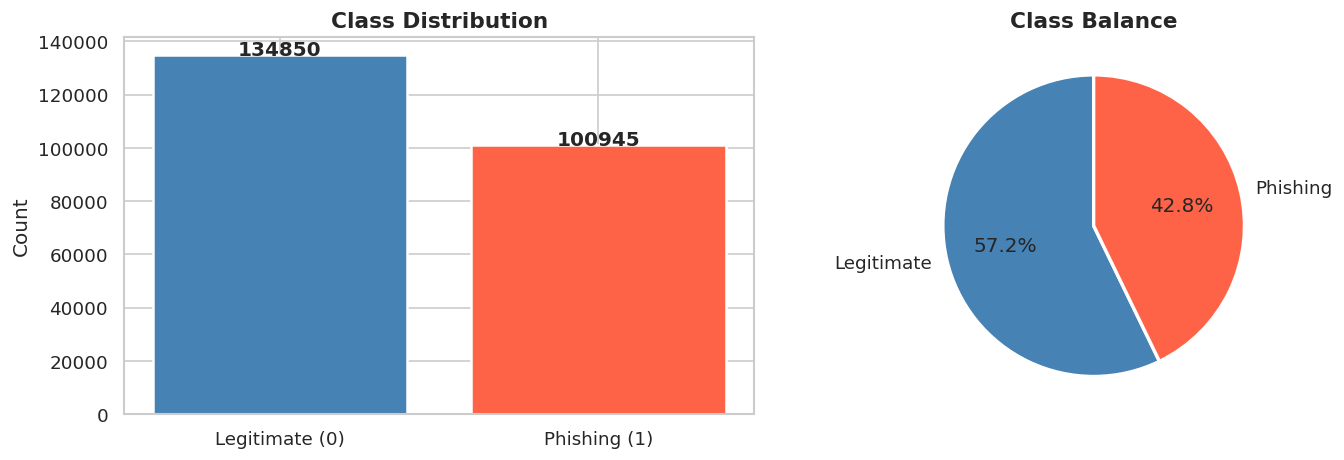

In [37]:
# ── Class balance ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[LABEL_COL].value_counts()
axes[0].bar(['Legitimate (0)', 'Phishing (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legitimate', 'Phishing'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

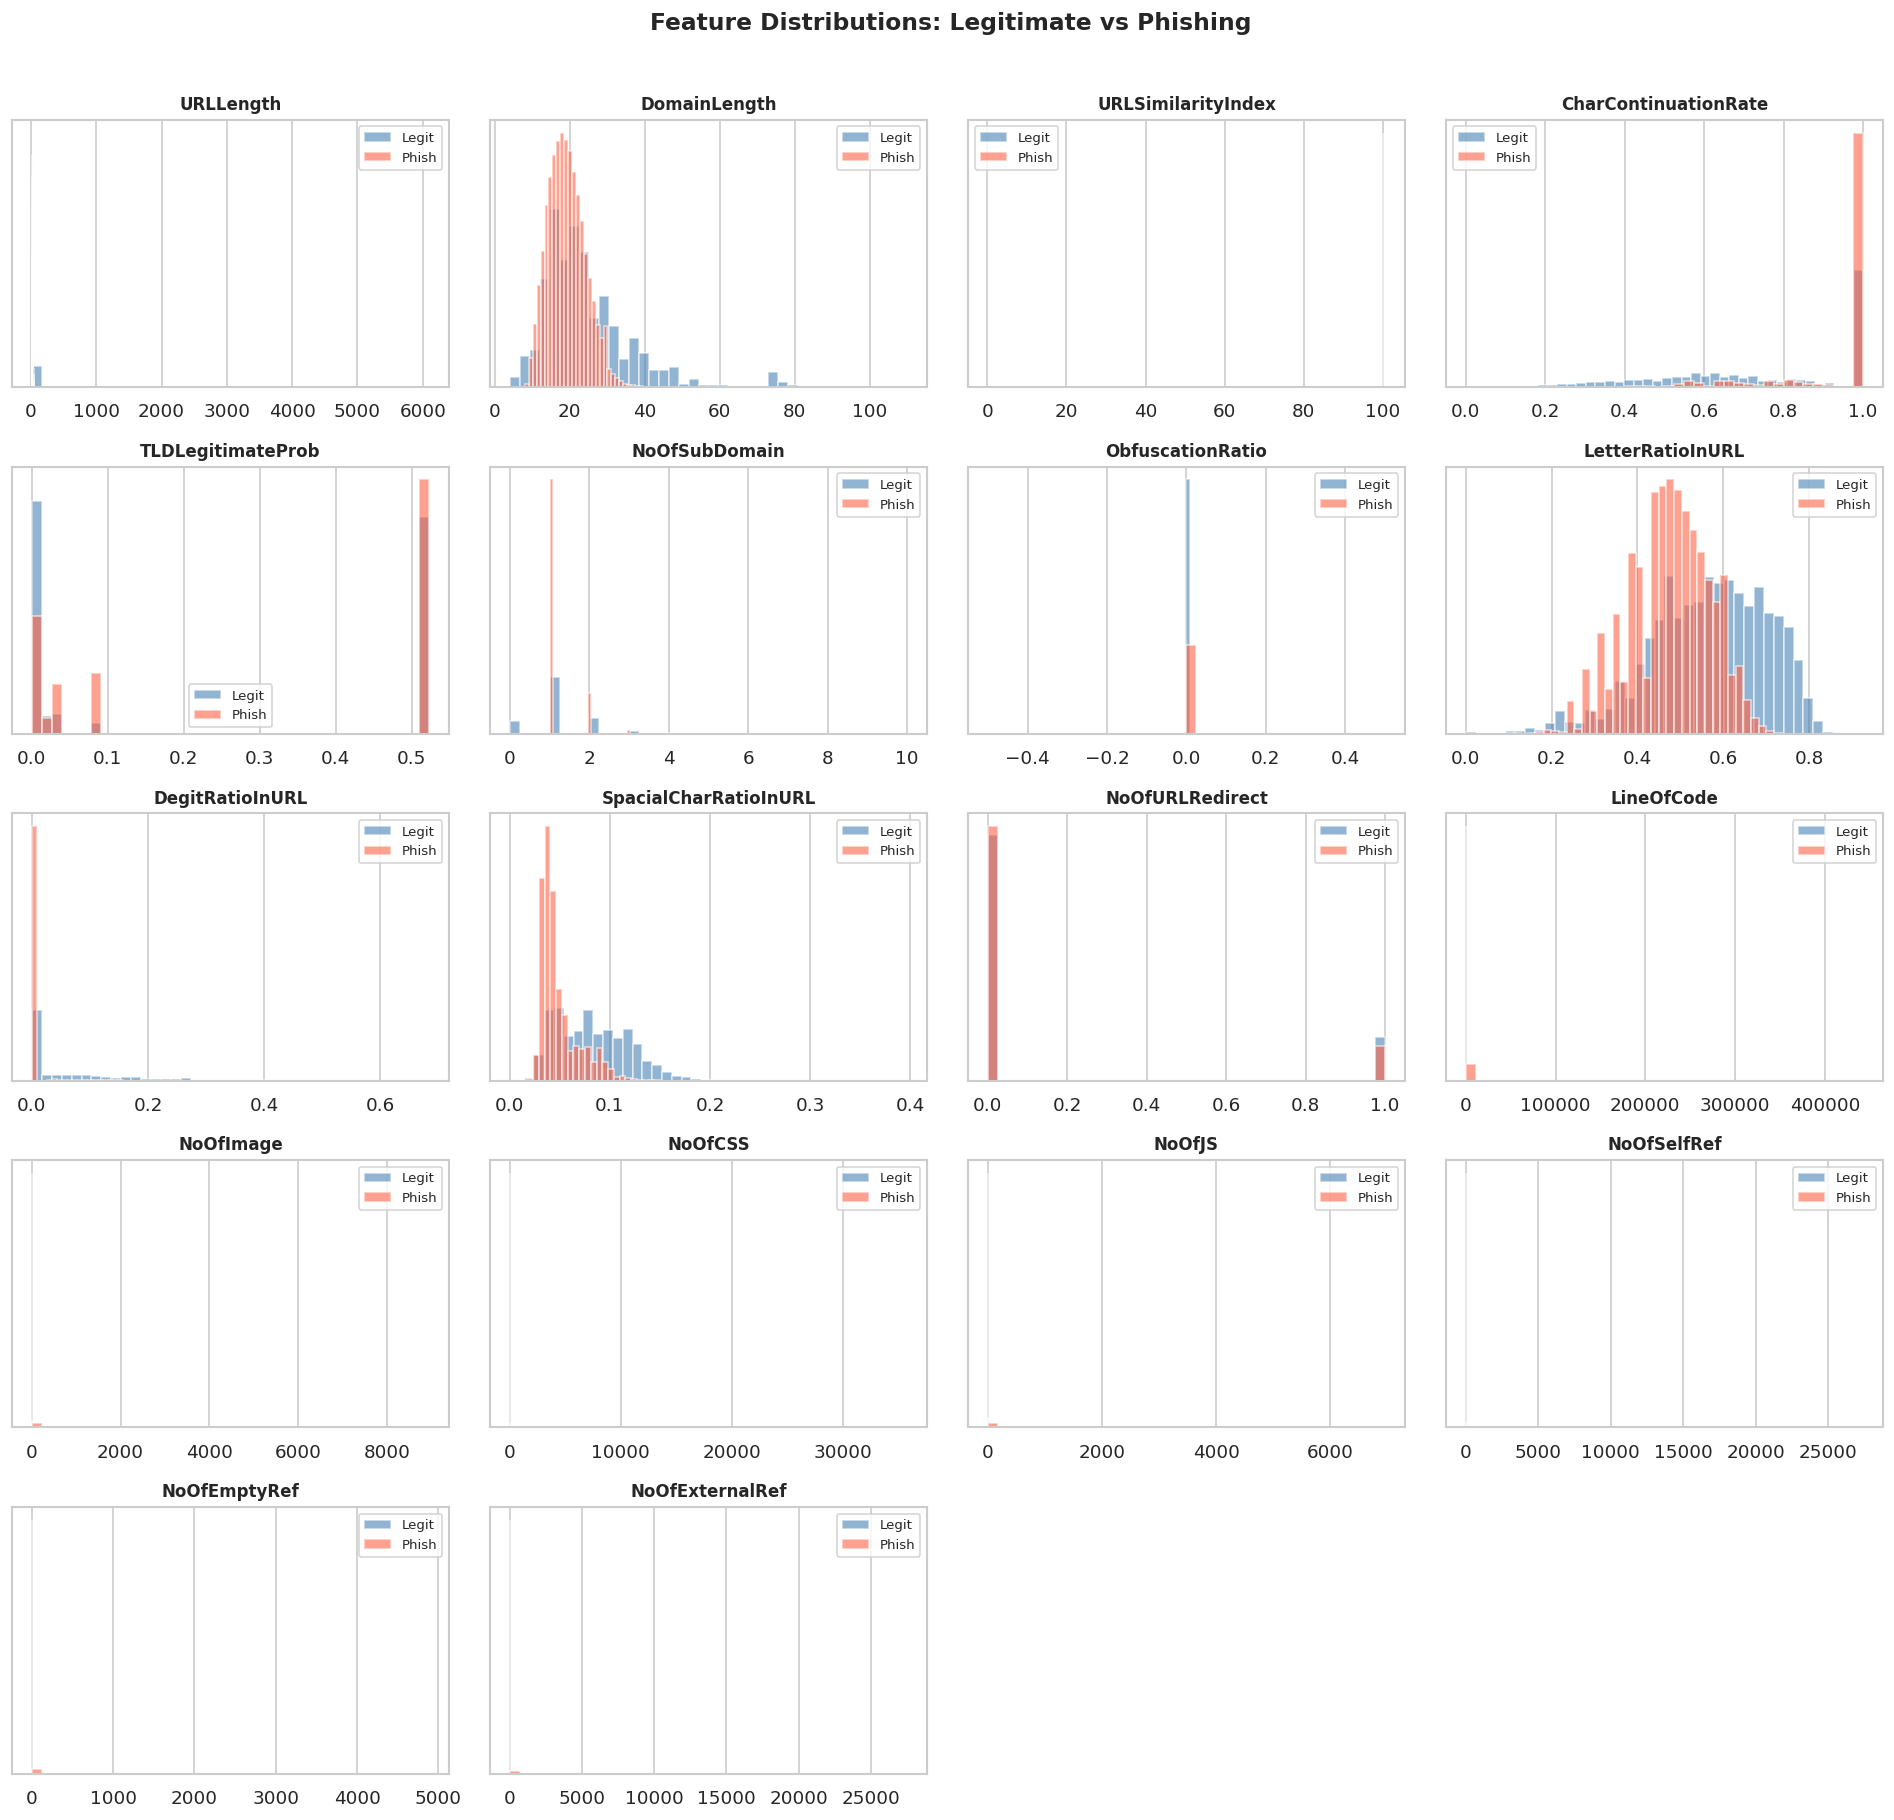

In [38]:
# ── Feature distributions by label ────────────────────────────────────
# Key numeric features to investigate
numeric_features = [
    'URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate',
    'TLDLegitimateProb', 'NoOfSubDomain', 'ObfuscationRatio',
    'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL',
    'NoOfURLRedirect', 'LineOfCode',
    # new columns
    'NoOfImage', 'NoOfCSS', 'NoOfJS',
    'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef'
]
# Filter to features actually in dataset
numeric_features = [f for f in numeric_features if f in df.columns]

n_cols = 4
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    for label_val, color, lname in [(0, 'steelblue', 'Legit'), (1, 'tomato', 'Phish')]:
        data = df[df[LABEL_COL] == label_val][feat].dropna()
        axes[i].hist(data, bins=40, alpha=0.6, color=color, label=lname, density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Legitimate vs Phishing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

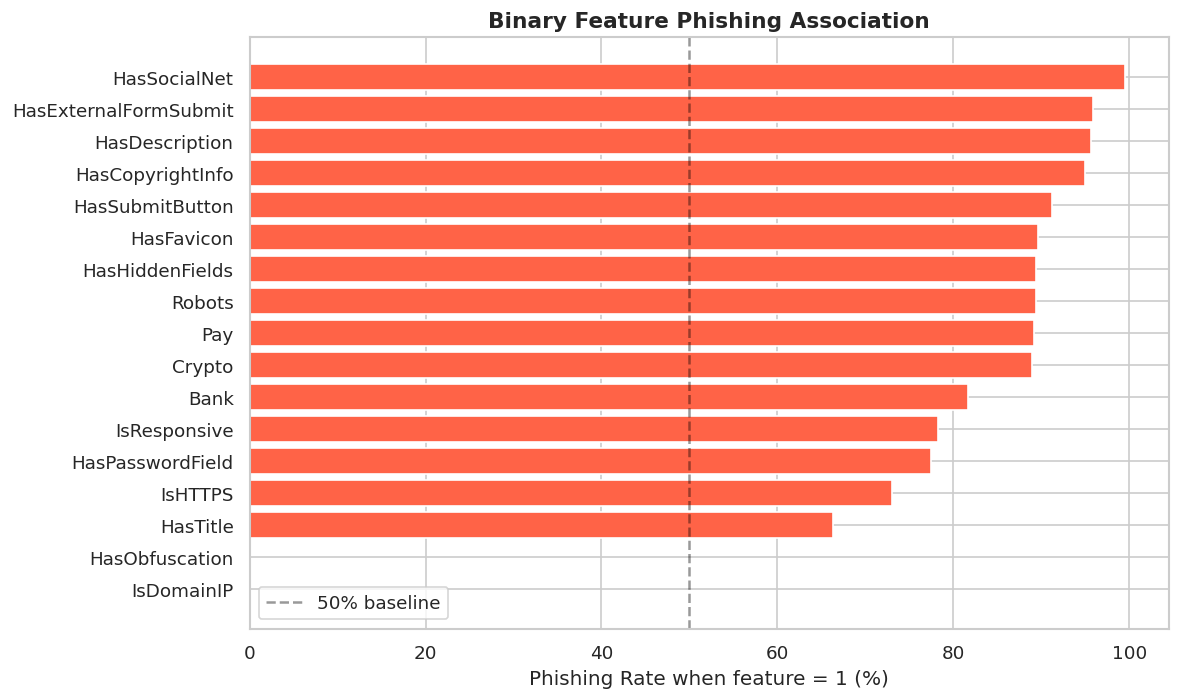

In [39]:
# ── Binary feature phishing rates ─────────────────────────────────────
binary_features = [
    'IsDomainIP', 'IsHTTPS', 'HasObfuscation', 'HasTitle', 'HasFavicon',
    'Robots', 'IsResponsive', 'HasDescription', 'HasExternalFormSubmit',
    'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField',
    # new columns
    'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo'
]
binary_features = [f for f in binary_features if f in df.columns]

phish_rates = {
    feat: df[df[feat] == 1][LABEL_COL].mean() * 100
    for feat in binary_features
}
phish_df = pd.DataFrame.from_dict(phish_rates, orient='index', columns=['Phishing Rate (%)'])
phish_df = phish_df.sort_values('Phishing Rate (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(phish_df.index, phish_df['Phishing Rate (%)'],
               color=['tomato' if x > 50 else 'steelblue' for x in phish_df['Phishing Rate (%)']])
ax.axvline(50, color='black', linestyle='--', alpha=0.4, label='50% baseline')
ax.set_xlabel('Phishing Rate when feature = 1 (%)')
ax.set_title('Binary Feature Phishing Association', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

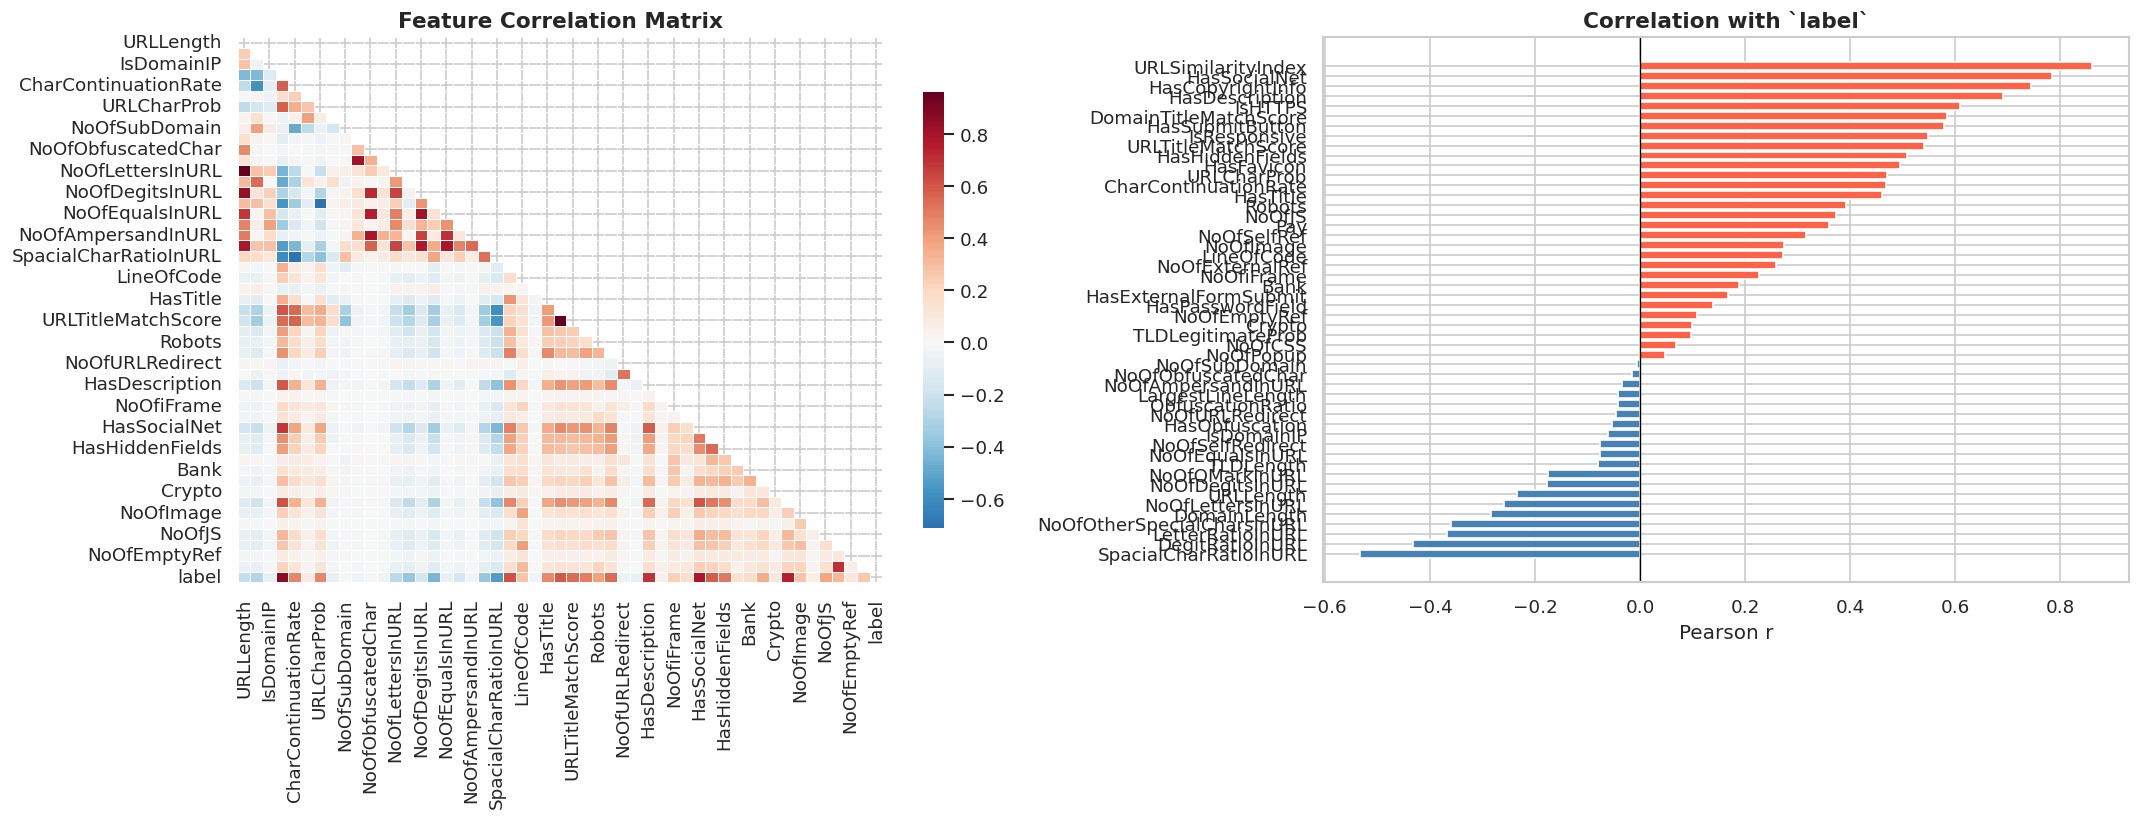

In [40]:
# ── Correlation heatmap ───────────────────────────────────────────────
# Drop non-numeric columns for correlation
drop_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
numeric_df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
numeric_df = numeric_df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

# Correlation with label
label_corr = corr[LABEL_COL].drop(LABEL_COL).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            linewidths=0.3, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

# Correlation with label
colors = ['tomato' if x > 0 else 'steelblue' for x in label_corr.values]
axes[1].barh(label_corr.index, label_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Correlation with `{LABEL_COL}`', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

## 3. Preprocessing & Feature Engineering <a id='3'></a>

In [41]:
# ── Feature Engineering ───────────────────────────────────────────────

df_fe = df.copy()

# 1. URL has suspicious keywords
suspicious_kw = ['login', 'signin', 'verify', 'account', 'update',
                 'secure', 'banking', 'paypal', 'ebay', 'amazon']
if 'URL' in df_fe.columns:
    df_fe['HasSuspiciousKeyword'] = df_fe['URL'].str.lower().apply(
        lambda u: int(any(kw in str(u) for kw in suspicious_kw))
    )

# 2. Digit-to-letter ratio in domain
if 'Domain' in df_fe.columns:
    df_fe['DomainDigitRatio'] = df_fe['Domain'].apply(
        lambda d: sum(c.isdigit() for c in str(d)) / max(len(str(d)), 1)
    )

# 3. TLD is suspicious (uncommon / high-risk TLDs)
risky_tlds = {'xyz', 'top', 'club', 'online', 'site', 'tk', 'ml', 'ga', 'cf', 'gq'}
if 'TLD' in df_fe.columns:
    df_fe['IsRiskyTLD'] = df_fe['TLD'].str.lower().isin(risky_tlds).astype(int)

# 4. URL has multiple subdomains
if 'NoOfSubDomain' in df_fe.columns:
    df_fe['HasMultipleSubdomains'] = (df_fe['NoOfSubDomain'] > 2).astype(int)

# 5. Interaction: long URL + obfuscation
if 'URLLength' in df_fe.columns and 'HasObfuscation' in df_fe.columns:
    df_fe['LongURL_WithObfuscation'] = (
        (df_fe['URLLength'] > df_fe['URLLength'].median()) &
        (df_fe['HasObfuscation'] == 1)
    ).astype(int)

# 6. No HTTPS + has password field = very suspicious
if 'IsHTTPS' in df_fe.columns and 'HasPasswordField' in df_fe.columns:
    df_fe['HTTP_WithPassword'] = (
        (df_fe['IsHTTPS'] == 0) & (df_fe['HasPasswordField'] == 1)
    ).astype(int)

print('✅ Feature engineering complete')
print(f'New features added: HasSuspiciousKeyword, DomainDigitRatio, IsRiskyTLD, '
      f'HasMultipleSubdomains, LongURL_WithObfuscation, HTTP_WithPassword')
print(f'Total columns: {df_fe.shape[1]}')

✅ Feature engineering complete
New features added: HasSuspiciousKeyword, DomainDigitRatio, IsRiskyTLD, HasMultipleSubdomains, LongURL_WithObfuscation, HTTP_WithPassword
Total columns: 62


In [42]:
# ── Prepare features and target ───────────────────────────────────────

DROP_COLS = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title', LABEL_COL]

# ── 1. Audit label column before casting ──────────────────────────────
n_total = len(df_fe)
n_nan   = df_fe[LABEL_COL].isna().sum()
n_inf   = np.isinf(pd.to_numeric(df_fe[LABEL_COL], errors='coerce')).sum()
n_bad   = n_nan + n_inf
print(f'Label column audit:')
print(f'  Total rows   : {n_total}')
print(f'  NaN rows     : {n_nan}')
print(f'  Inf rows     : {n_inf}')
print(f'  Dropped rows : {n_bad}')

# ── 2. Drop rows where label is NaN or inf ────────────────────────────
label_numeric = pd.to_numeric(df_fe[LABEL_COL], errors='coerce')
valid_mask    = label_numeric.notna() & np.isfinite(label_numeric)
df_clean      = df_fe[valid_mask].copy()
df_clean[LABEL_COL] = label_numeric[valid_mask].astype(int)

print(f'\nRows remaining after cleaning: {len(df_clean)}')
print(df_clean[LABEL_COL].value_counts())

# ── 3. Build X and y ──────────────────────────────────────────────────
X = df_clean.drop(columns=[c for c in DROP_COLS if c in df_clean.columns], errors='ignore')
y = df_clean[LABEL_COL]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

print(f'\nFeatures shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(list(X.columns))

Label column audit:
  Total rows   : 235795
  NaN rows     : 0
  Inf rows     : 0
  Dropped rows : 0

Rows remaining after cleaning: 235795
label
1    134850
0    100945
Name: count, dtype: int64

Features shape : (235795, 56)
Target shape   : (235795,)
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'P

In [43]:
# ── Train / Test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y      # preserve class balance
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train phishing rate: {y_train.mean()*100:.2f}%')
print(f'Test  phishing rate: {y_test.mean()*100:.2f}%')

Train: (188636, 56)  |  Test: (47159, 56)
Train phishing rate: 57.19%
Test  phishing rate: 57.19%


In [44]:
# ── Impute missing values ─────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns)

print(f'Remaining nulls in train: {X_train_imp.isnull().sum().sum()}')
print(f'Remaining nulls in test:  {X_test_imp.isnull().sum().sum()}')

Remaining nulls in train: 0
Remaining nulls in test:  0


In [45]:
# ── Handle class imbalance (if needed) ────────────────────────────────
# Check imbalance ratio
ratio = y_train.value_counts()
imbalance = ratio.min() / ratio.max()
print(f'Class imbalance ratio: {imbalance:.3f}  (1.0 = perfectly balanced)')

# Note: XGBoost has built-in scale_pos_weight; RandomForest has class_weight='balanced'
# If severely imbalanced (< 0.3), consider SMOTE:
# from imblearn.over_sampling import SMOTE
# X_train_imp, y_train = SMOTE(random_state=42).fit_resample(X_train_imp, y_train)

scale_pos_weight = ratio[0] / ratio[1]   # for XGBoost
print(f'scale_pos_weight for XGBoost: {scale_pos_weight:.3f}')

Class imbalance ratio: 0.749  (1.0 = perfectly balanced)
scale_pos_weight for XGBoost: 0.749


In [58]:
# 1. Correlation audit
corr = X_train_imp.corrwith(y_train).abs().sort_values(ascending=False)
print("Top correlated features:")
print(corr.head(20))

# 2. Drop suspicious features + duplicates
LEAKAGE_COLS = ['URLSimilarityIndex']   # add others if correlation > 0.95
DROP_COLS = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title', LABEL_COL] + LEAKAGE_COLS

df_clean = df_clean.drop_duplicates()

Top correlated features:
HasObfuscation                0.006163
LongURL_WithObfuscation       0.006163
ObfuscationRatio              0.005096
NoOfiFrame                    0.004411
NoOfAmpersandInURL            0.004343
NoOfLettersInURL              0.004343
URLLength                     0.004237
IsRiskyTLD                    0.003901
LetterRatioInURL              0.003796
NoOfOtherSpecialCharsInURL    0.003500
LargestLineLength             0.003396
NoOfQMarkInURL                0.003238
NoOfJS                        0.003057
NoOfEqualsInURL               0.003018
HasSuspiciousKeyword          0.002980
DegitRatioInURL               0.002953
IsHTTPS                       0.002945
URLSimilarityIndex            0.002943
NoOfURLRedirect               0.002937
NoOfDegitsInURL               0.002841
dtype: float64


## 4. Model Training & Hyperparameter Tuning <a id='4'></a>

In [46]:
# ── Cross-validation strategy ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'f1'   # good for imbalanced; change to 'roc_auc' if preferred

In [47]:
# ── Random Forest — Hyperparameter Tuning ─────────────────────────────

rf_param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'class_weight':      ['balanced', 'balanced_subsample', None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, max_samples=0.5)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_dist,
    n_iter=30,            # increase for broader search
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

rf_search.fit(X_train_imp, y_train)

print(f'\n✅ Best RF params:  {rf_search.best_params_}')
print(f'   Best CV {SCORING}: {rf_search.best_score_:.4f}')

rf_best = rf_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best RF params:  {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced'}
   Best CV f1: 1.0000


In [48]:
# ── XGBoost — Hyperparameter Tuning ───────────────────────────────────

xgb_param_dist = {
    'n_estimators':   [100, 200, 300, 500],
    'max_depth':      [3, 5, 7, 9],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':          [0, 0.1, 0.3, 0.5],
    'reg_alpha':      [0, 0.1, 0.5],      # L1
    'reg_lambda':     [1, 1.5, 2.0],      # L2
    'scale_pos_weight': [1, scale_pos_weight]  # imbalance
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

xgb_search.fit(X_train_imp, y_train)

print(f'\n✅ Best XGB params: {xgb_search.best_params_}')
print(f'   Best CV {SCORING}: {xgb_search.best_score_:.4f}')

xgb_best = xgb_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best XGB params: {'subsample': 0.8, 'scale_pos_weight': np.float64(0.7485724879495737), 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}
   Best CV f1: 1.0000


,model,best_cv_score
0,Random Forest,0.999995
1,XGBoost,0.999991


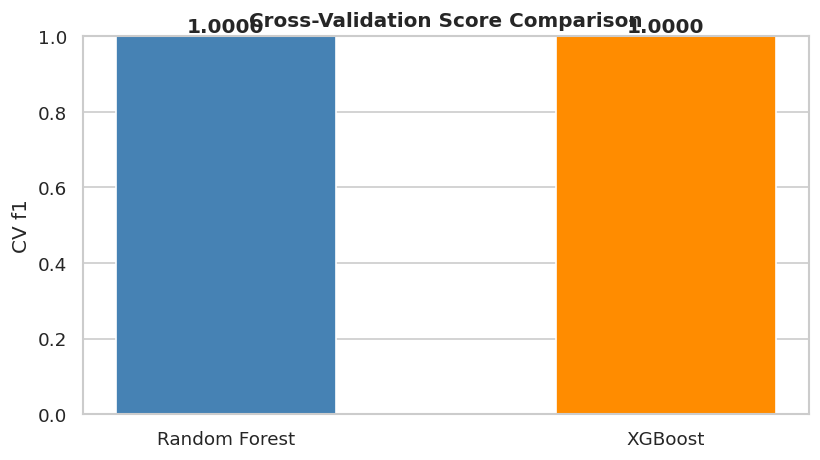

In [49]:
# ── Cross-validation score comparison ────────────────────────────────
cv_results = pd.DataFrame({
    'model': ['Random Forest', 'XGBoost'],
    'best_cv_score': [rf_search.best_score_, xgb_search.best_score_],
    'best_params': [rf_search.best_params_, xgb_search.best_params_]
})
display(cv_results[['model', 'best_cv_score']])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cv_results['model'], cv_results['best_cv_score'],
       color=['steelblue', 'darkorange'], width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel(f'CV {SCORING}')
ax.set_title('Cross-Validation Score Comparison', fontweight='bold')
for i, v in enumerate(cv_results['best_cv_score']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Model Evaluation & Comparison <a id='5'></a>

In [50]:
# ── Evaluation helper ─────────────────────────────────────────────────

def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    }
    return metrics, y_prob, y_pred

rf_metrics,  rf_probs,  rf_preds  = evaluate_model('Random Forest', rf_best,  X_test_imp, y_test)
xgb_metrics, xgb_probs, xgb_preds = evaluate_model('XGBoost',       xgb_best, X_test_imp, y_test)

results_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('Model').round(4)
display(results_df.style.highlight_max(axis=0, color='lightgreen'))

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000


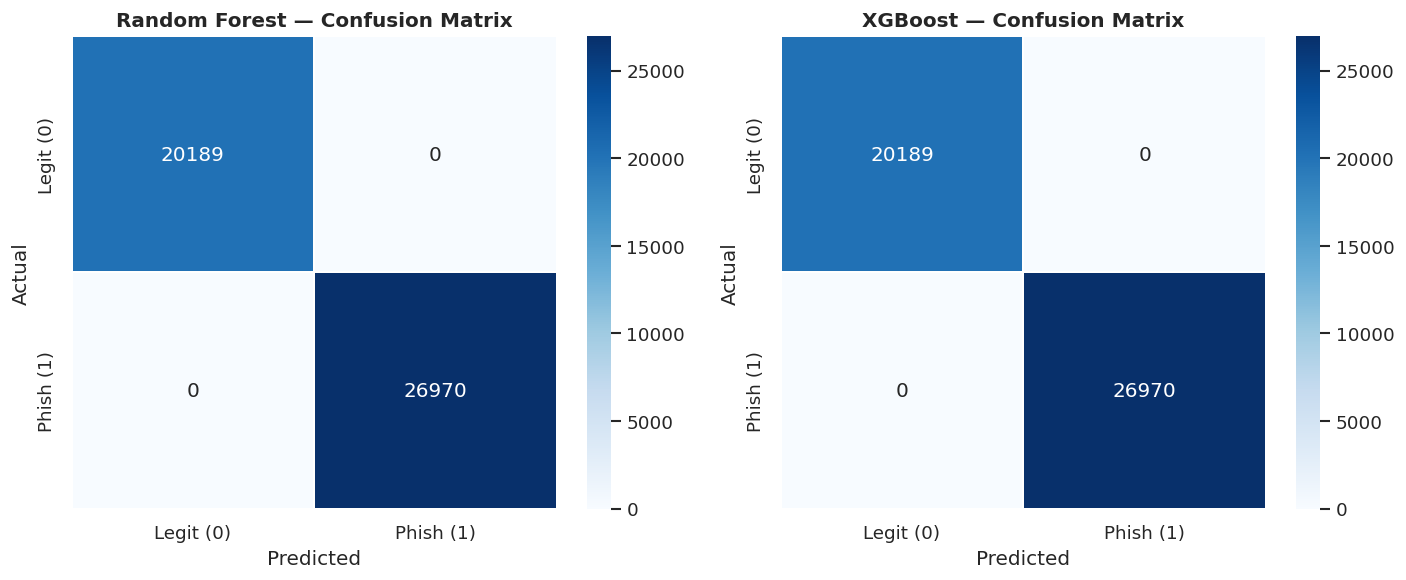

In [51]:
# ── Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, preds in zip(axes,
                            ['Random Forest', 'XGBoost'],
                            [rf_preds, xgb_preds]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit (0)', 'Phish (1)'],
                yticklabels=['Legit (0)', 'Phish (1)'],
                linewidths=1, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

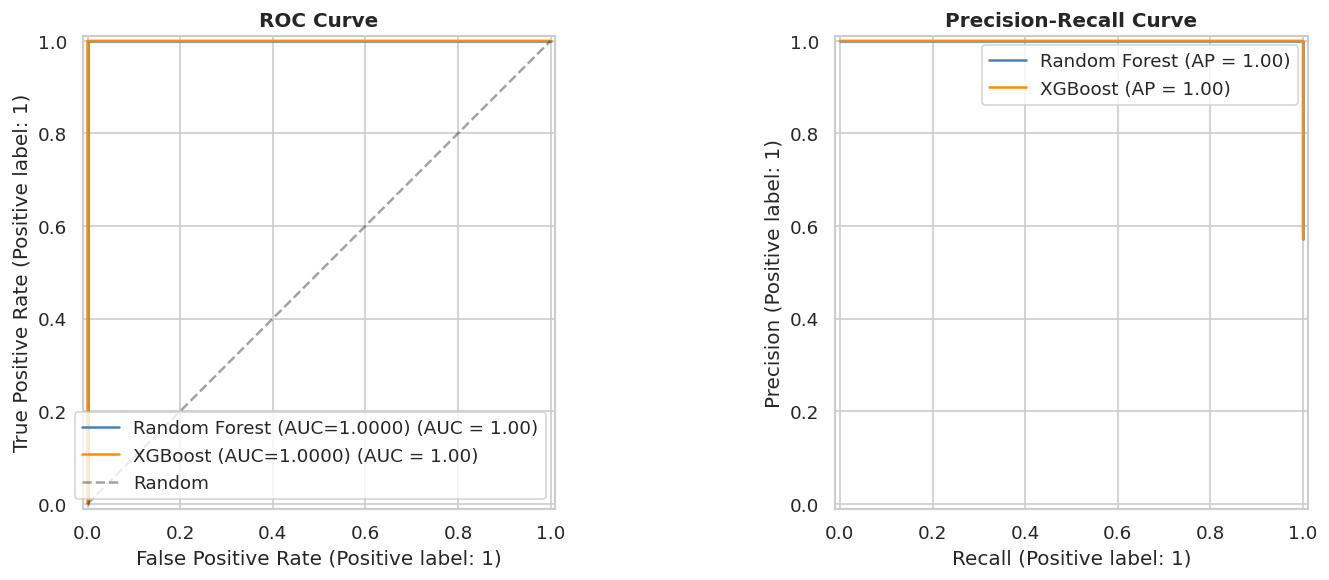

In [52]:
# ── ROC & Precision-Recall Curves ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for name, probs, color in [
    ('Random Forest', rf_probs,  'steelblue'),
    ('XGBoost',       xgb_probs, 'darkorange')
]:
    auc = roc_auc_score(y_test, probs)
    RocCurveDisplay.from_predictions(
        y_test, probs, name=f'{name} (AUC={auc:.4f})',
        ax=axes[0], color=color
    )
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right')

# Precision-Recall
for name, probs, color in [
    ('Random Forest', rf_probs,  'steelblue'),
    ('XGBoost',       xgb_probs, 'darkorange')
]:
    PrecisionRecallDisplay.from_predictions(
        y_test, probs, name=name, ax=axes[1], color=color
    )
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
# ── Detailed Classification Reports ───────────────────────────────────
for name, preds in [('Random Forest', rf_preds), ('XGBoost', xgb_preds)]:
    print(f'{'─'*50}')
    print(f'  {name}')
    print(f'{'─'*50}')
    print(classification_report(y_test, preds,
                                target_names=['Legitimate', 'Phishing']))

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



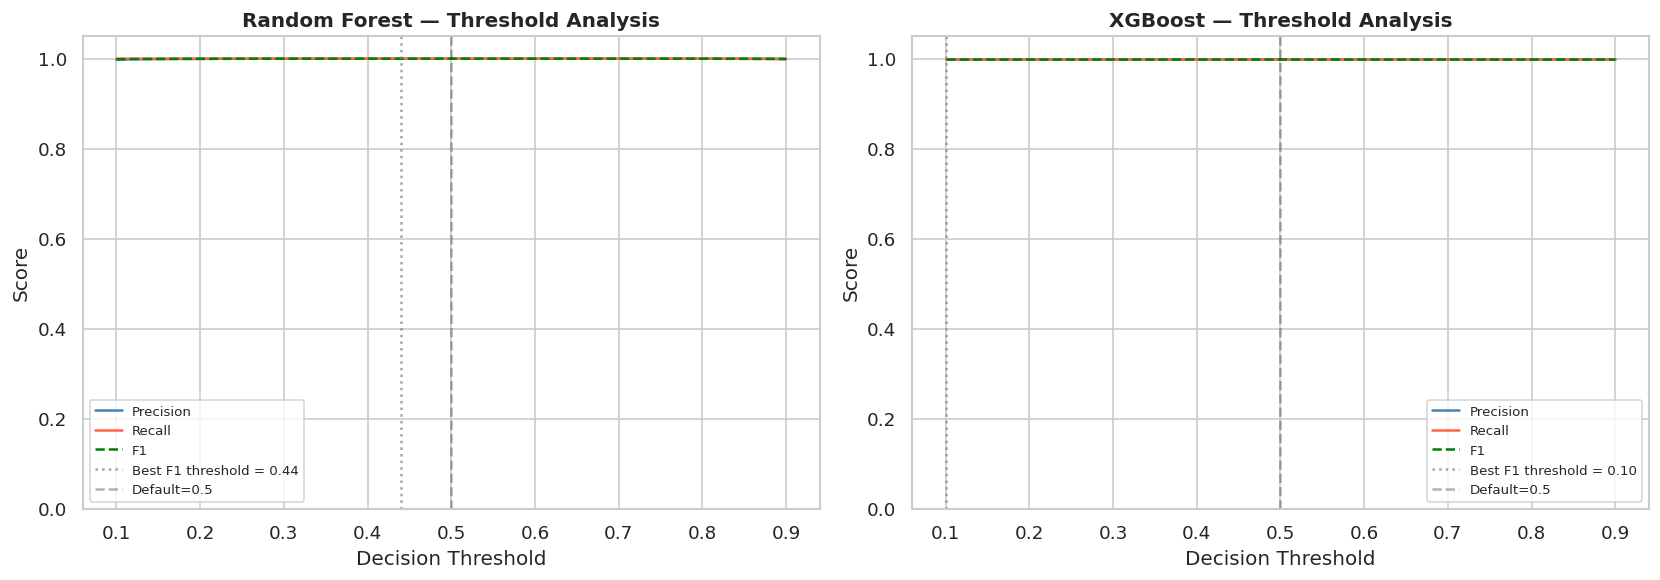

In [54]:
# ── Threshold Analysis ────────────────────────────────────────────────
# In phishing detection, high Recall matters (don't miss phish)
# Explore trade-off at different thresholds

thresholds = np.linspace(0.1, 0.9, 81)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, probs in [
    (axes[0], 'Random Forest', rf_probs),
    (axes[1], 'XGBoost',       xgb_probs)
]:
    precisions, recalls, f1s = [], [], []
    for t in thresholds:
        preds_t = (probs >= t).astype(int)
        precisions.append(precision_score(y_test, preds_t, zero_division=0))
        recalls.append(recall_score(y_test, preds_t, zero_division=0))
        f1s.append(f1_score(y_test, preds_t, zero_division=0))

    ax.plot(thresholds, precisions, label='Precision', color='steelblue')
    ax.plot(thresholds, recalls,    label='Recall',    color='tomato')
    ax.plot(thresholds, f1s,        label='F1',        color='green', linestyle='--')

    best_t = thresholds[np.argmax(f1s)]
    ax.axvline(best_t, color='grey', linestyle=':', alpha=0.7,
               label=f'Best F1 threshold = {best_t:.2f}')
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.3, label='Default=0.5')

    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{name} — Threshold Analysis', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis <a id='6'></a>

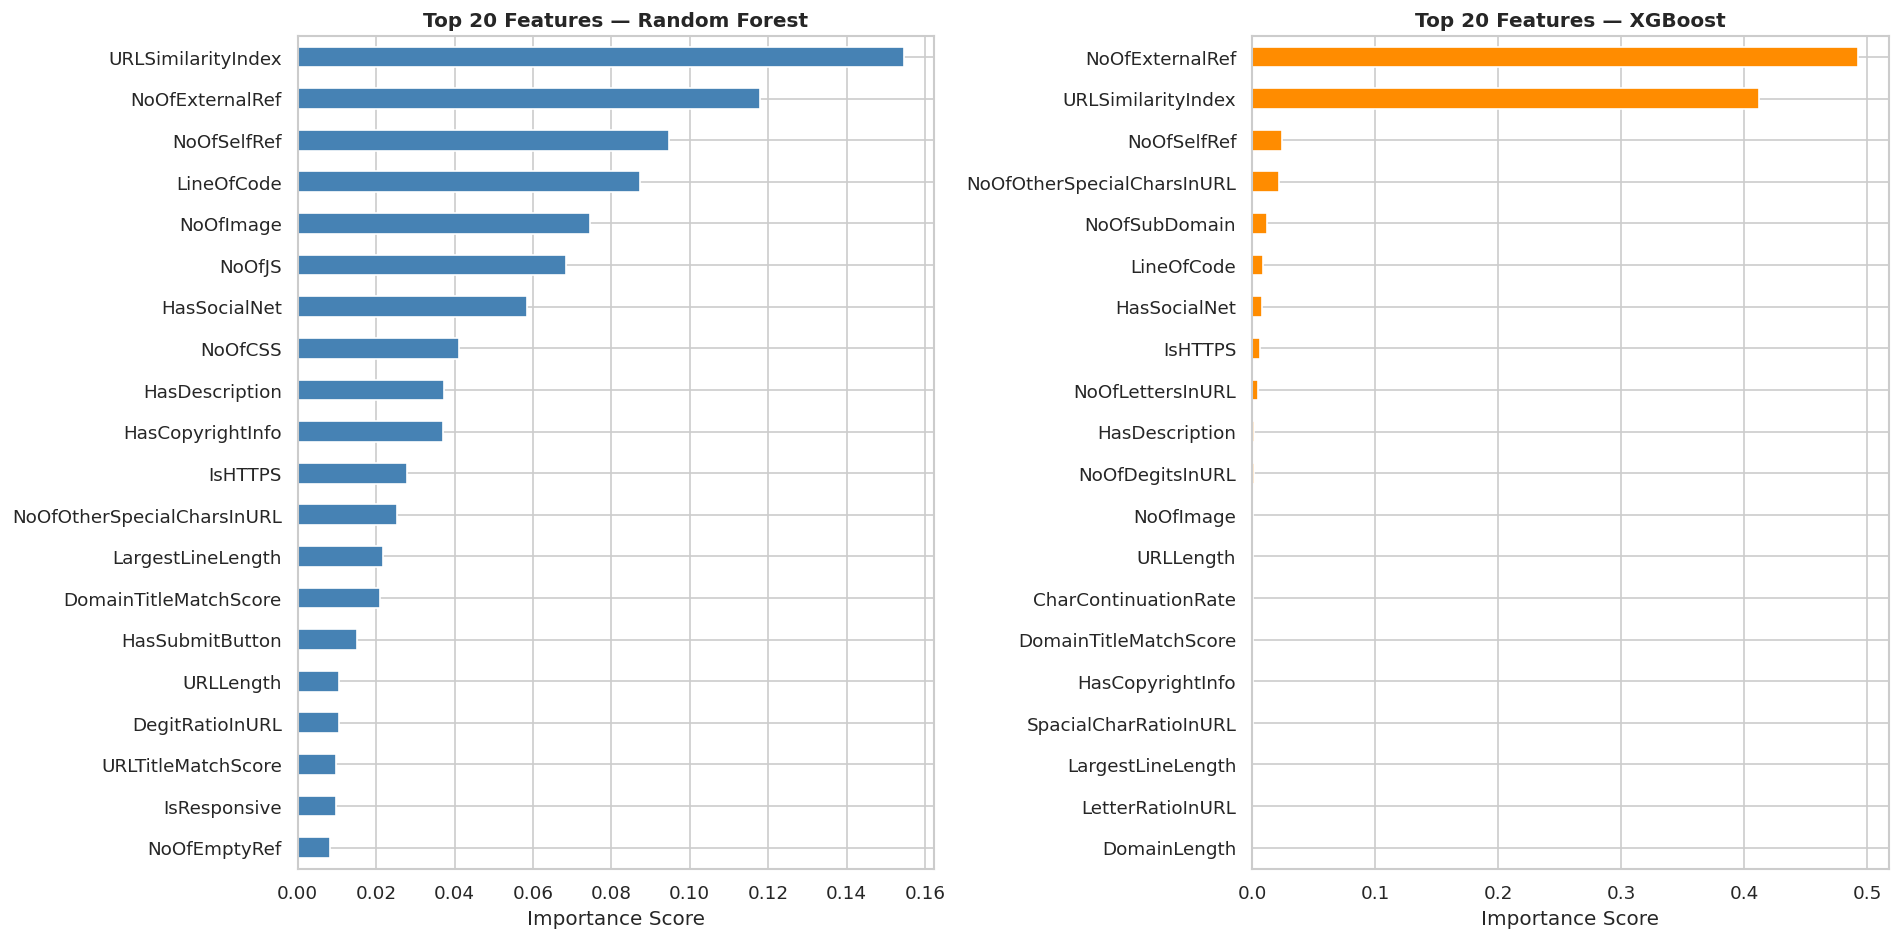

In [55]:
# ── Feature Importance Comparison ─────────────────────────────────────
feat_names = X_train_imp.columns.tolist()

rf_imp  = pd.Series(rf_best.feature_importances_,  index=feat_names)
xgb_imp = pd.Series(xgb_best.feature_importances_, index=feat_names)

top_n = 20
rf_top  = rf_imp.nlargest(top_n)
xgb_top = xgb_imp.nlargest(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, name, imp, color in [
    (axes[0], 'Random Forest', rf_top,  'steelblue'),
    (axes[1], 'XGBoost',       xgb_top, 'darkorange')
]:
    imp.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Top {top_n} Features — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [ ]:
# ── Combined importance rank table ───────────────────────────────────
importance_df = pd.DataFrame({
    'RF_importance':  rf_imp,
    'XGB_importance': xgb_imp
})
importance_df['RF_rank']  = importance_df['RF_importance'].rank(ascending=False).astype(int)
importance_df['XGB_rank'] = importance_df['XGB_importance'].rank(ascending=False).astype(int)
importance_df['avg_rank'] = (importance_df['RF_rank'] + importance_df['XGB_rank']) / 2

top_combined = importance_df.sort_values('avg_rank').head(20)
display(top_combined.style.background_gradient(subset=['RF_importance', 'XGB_importance'],
                                                cmap='YlOrRd'))

## 7. Saving Models <a id='7'></a>

In [56]:
# ── Save models and imputer ───────────────────────────────────────────
joblib.dump(rf_best,  'rf_phishing_model.pkl')
joblib.dump(xgb_best, 'xgb_phishing_model.pkl')
joblib.dump(imputer,  'imputer.pkl')

print('✅ Models saved:')
print('   rf_phishing_model.pkl')
print('   xgb_phishing_model.pkl')
print('   imputer.pkl')

✅ Models saved:
   rf_phishing_model.pkl
   xgb_phishing_model.pkl
   imputer.pkl


In [57]:
# ── Inference example: single URL prediction ──────────────────────────
def predict_url(feature_dict, model, imputer, feature_cols, threshold=0.5):
    """
    Predict whether a single URL is phishing.
    feature_dict: dict of {feature_name: value} for one URL
    """
    row = pd.DataFrame([feature_dict])
    # Align columns
    row = row.reindex(columns=feature_cols, fill_value=0)
    row_imp = imputer.transform(row)
    prob = model.predict_proba(row_imp)[0, 1]
    label = 'PHISHING 🎣' if prob >= threshold else 'LEGITIMATE ✅'
    print(f'Probability: {prob:.4f}  →  {label}')
    return prob

# Example (fill in real values)
example = {col: X_test_imp.iloc[0][col] for col in X_train_imp.columns}
predict_url(example, xgb_best, imputer, X_train_imp.columns.tolist())

Probability: 1.0000  →  PHISHING 🎣


np.float32(0.999995)

## 8. overfitting check with a proper cross-validation check: <a id='7'></a>

In [60]:
from sklearn.model_selection import cross_val_score

# Test on completely unseen folds
rf_cv_scores = cross_val_score(rf_best, X_train_imp, y_train,
                                cv=5, scoring='f1', n_jobs=-1)
xgb_cv_scores = cross_val_score(xgb_best, X_train_imp, y_train,
                                 cv=5, scoring='f1', n_jobs=-1)

print(f'RF  CV F1:  {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')
print(f'XGB CV F1: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}')

RF  CV F1:  1.0000 ± 0.0000
XGB CV F1: 1.0000 ± 0.0000


## 8.  Compare model efficiency <a id='7'></a>

In [62]:
import time

start = time.time()
rf_best.predict(X_test_imp)
print(f'RF  inference time: {time.time()-start:.4f}s')

start = time.time()
xgb_best.predict(X_test_imp)
print(f'XGB inference time: {time.time()-start:.4f}s')

RF  inference time: 3.1827s
XGB inference time: 0.1701s


## 10. SHAP explainability (strongest addition for a project)<a id='7'></a>

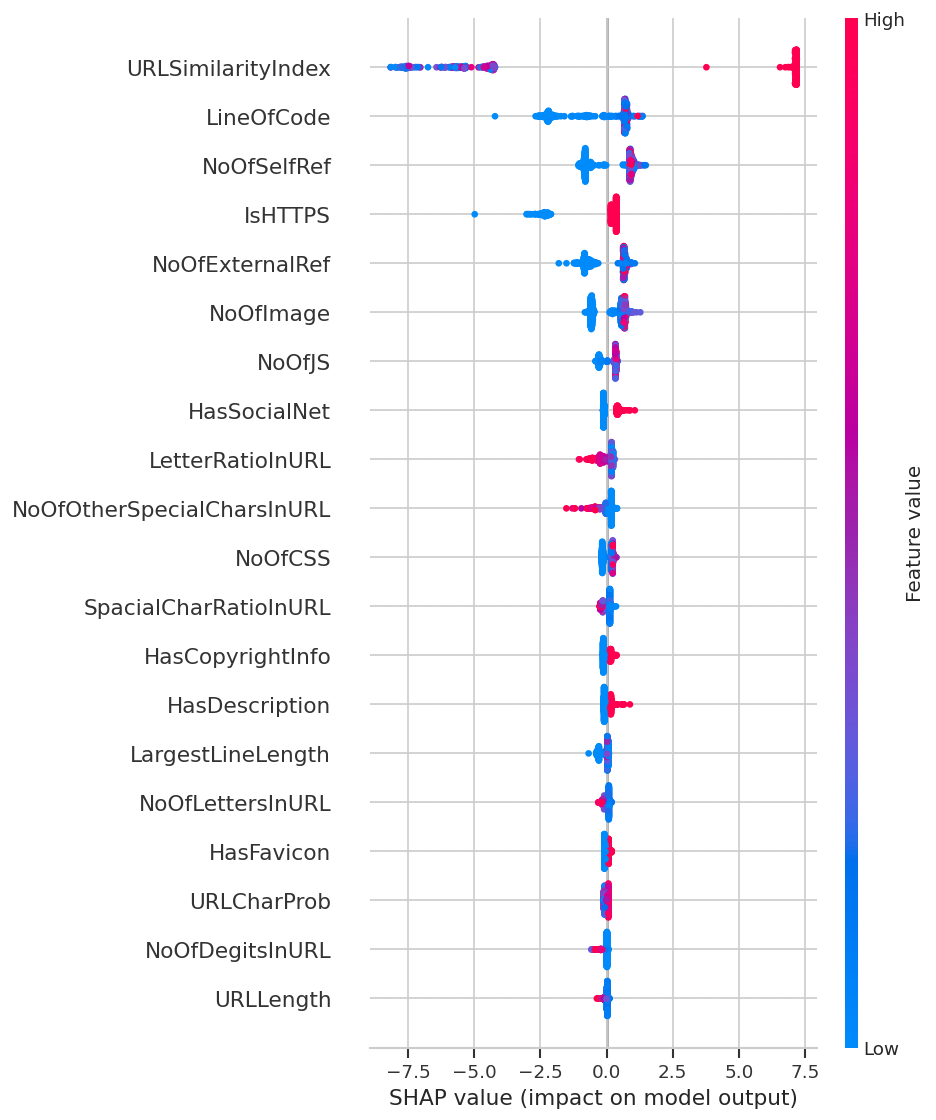

In [65]:
import shap
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_imp.iloc[:500])
shap.summary_plot(shap_values, X_test_imp.iloc[:500])

In [66]:
import time

start = time.time()
rf_best.predict(X_test_imp)
print(f'RF  inference time: {time.time()-start:.4f}s')

start = time.time()
xgb_best.predict(X_test_imp)
print(f'XGB inference time: {time.time()-start:.4f}s')

RF  inference time: 3.2248s
XGB inference time: 0.2120s



2. Save both models (you'll need them for the new dataset)


In [67]:
import joblib
joblib.dump(rf_best,  'rf_phishing_model.pkl')
joblib.dump(xgb_best, 'xgb_phishing_model.pkl')
joblib.dump(imputer,  'imputer.pkl')
print('✅ Models saved')

✅ Models saved


## PHASE 2 — Cross-Dataset Evaluation (Mapping → Results) <a id='7'></a>

In [69]:


import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)


In [70]:
# ── 1. Load new dataset ───────────────────────────────────────────────
df2 = pd.read_csv('/content/drive/MyDrive/Phishing URL Detection using Machine Learning/dataset_phishing.csv')
print(f'Shape: {df2.shape}')
print(df2['status'].value_counts())

# Encode label: legitimate=0, phishing=1
df2['label'] = (df2['status'] == 'phishing').astype(int)
print(f'\nEncoded label distribution:')
print(df2['label'].value_counts())

Shape: (11430, 89)
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Encoded label distribution:
label
0    5715
1    5715
Name: count, dtype: int64


In [71]:
# ── 2. Feature mapping (dataset_phishing → PhiUSIIL naming) ──────────
# Map columns that represent the same concept under different names
feature_map = {
    'length_url'              : 'URLLength',
    'length_hostname'         : 'DomainLength',
    'ip'                      : 'IsDomainIP',
    'nb_qm'                   : 'NoOfQMarkInURL',
    'nb_and'                  : 'NoOfAmpersandInURL',
    'nb_eq'                   : 'NoOfEqualsInURL',
    'ratio_digits_url'        : 'DegitRatioInURL',
    'nb_subdomains'           : 'NoOfSubDomain',
    'nb_redirection'          : 'NoOfURLRedirect',
    'nb_external_redirection' : 'NoOfSelfRedirect',
    'login_form'              : 'HasExternalFormSubmit',
    'external_favicon'        : 'HasFavicon',
    'iframe'                  : 'NoOfiFrame',
    'popup_window'            : 'NoOfPopup',
    'domain_with_copyright'   : 'HasCopyrightInfo',
    'https_token'             : 'IsHTTPS',
    'nb_extCSS'               : 'NoOfCSS',
    'submit_email'            : 'HasSubmitButton',
    'empty_title'             : 'HasTitle',
    'domain_in_title'         : 'DomainTitleMatchScore',
}

df2_mapped = df2.rename(columns=feature_map)
print(f'Mapped {len(feature_map)} features successfully')

Mapped 20 features successfully


In [72]:
# ── 3. Load saved models + training feature list ──────────────────────
rf_loaded  = joblib.load('rf_phishing_model.pkl')
xgb_loaded = joblib.load('xgb_phishing_model.pkl')
imputer    = joblib.load('imputer.pkl')

# Features the model was trained on
trained_features = X_train_imp.columns.tolist()
print(f'Model expects {len(trained_features)} features')

# Check overlap
available = set(df2_mapped.columns)
matched   = [f for f in trained_features if f in available]
missing   = [f for f in trained_features if f not in available]
print(f'Matched features : {len(matched)}')
print(f'Missing features : {len(missing)}')
print(f'\nMissing: {missing}')

Model expects 56 features
Matched features : 20
Missing features : 36

Missing: ['URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'LineOfCode', 'LargestLineLength', 'URLTitleMatchScore', 'Robots', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'NoOfImage', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'HasSuspiciousKeyword', 'DomainDigitRatio', 'IsRiskyTLD', 'HasMultipleSubdomains', 'LongURL_WithObfuscation', 'HTTP_WithPassword']


In [73]:
# ── 4. Align + fill missing features with 0 ──────────────────────────
X2 = df2_mapped.reindex(columns=trained_features)
X2 = X2.fillna(0)
y2 = df2_mapped['label']

print(f'Aligned X2 shape: {X2.shape}')

Aligned X2 shape: (11430, 56)


In [74]:
# ── 5. Test pre-trained models on new dataset ─────────────────────────
X2_imp = pd.DataFrame(imputer.transform(X2), columns=trained_features)

rf_probs2  = rf_loaded.predict_proba(X2_imp)[:, 1]
xgb_probs2 = xgb_loaded.predict_proba(X2_imp)[:, 1]
rf_preds2  = (rf_probs2  >= 0.5).astype(int)
xgb_preds2 = (xgb_probs2 >= 0.5).astype(int)

results_phase2 = pd.DataFrame([
    {
        'Model'    : 'Random Forest (pretrained)',
        'Accuracy' : accuracy_score(y2, rf_preds2),
        'Precision': precision_score(y2, rf_preds2),
        'Recall'   : recall_score(y2, rf_preds2),
        'F1'       : f1_score(y2, rf_preds2),
        'ROC-AUC'  : roc_auc_score(y2, rf_probs2)
    },
    {
        'Model'    : 'XGBoost (pretrained)',
        'Accuracy' : accuracy_score(y2, xgb_preds2),
        'Precision': precision_score(y2, xgb_preds2),
        'Recall'   : recall_score(y2, xgb_preds2),
        'F1'       : f1_score(y2, xgb_preds2),
        'ROC-AUC'  : roc_auc_score(y2, xgb_probs2)
    }
]).set_index('Model').round(4)

display(results_phase2)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest (pretrained),0.5,0.0,0.0,0.0,0.3917
XGBoost (pretrained),0.5,0.0,0.0,0.0,0.4139


In [75]:
# ── 6. Train fresh models on new dataset ─────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_imp, y2, test_size=0.2, random_state=42, stratify=y2
)

# Fresh RF
rf_new = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=5,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=42
)
rf_new.fit(X2_train, y2_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [76]:
xgb_new = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    n_jobs=-1, random_state=42
)
xgb_new.fit(X2_train, y2_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [77]:
# Evaluate
rf_probs2_new  = rf_new.predict_proba(X2_test)[:, 1]
xgb_probs2_new = xgb_new.predict_proba(X2_test)[:, 1]
rf_preds2_new  = (rf_probs2_new  >= 0.5).astype(int)
xgb_preds2_new = (xgb_probs2_new >= 0.5).astype(int)

results_fresh = pd.DataFrame([
    {
        'Model'    : 'Random Forest (retrained)',
        'Accuracy' : accuracy_score(y2_test, rf_preds2_new),
        'Precision': precision_score(y2_test, rf_preds2_new),
        'Recall'   : recall_score(y2_test, rf_preds2_new),
        'F1'       : f1_score(y2_test, rf_preds2_new),
        'ROC-AUC'  : roc_auc_score(y2_test, rf_probs2_new)
    },
    {
        'Model'    : 'XGBoost (retrained)',
        'Accuracy' : accuracy_score(y2_test, xgb_preds2_new),
        'Precision': precision_score(y2_test, xgb_preds2_new),
        'Recall'   : recall_score(y2_test, xgb_preds2_new),
        'F1'       : f1_score(y2_test, xgb_preds2_new),
        'ROC-AUC'  : roc_auc_score(y2_test, xgb_probs2_new)
    }
]).set_index('Model').round(4)

display(results_fresh)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest (retrained),0.8543,0.8695,0.8338,0.8513,0.9359
XGBoost (retrained),0.8504,0.8651,0.8303,0.8473,0.9322


In [78]:
# Cross-validation check
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv  = cross_val_score(rf_new,  X2_imp, y2, cv=cv, scoring='f1', n_jobs=-1)
xgb_cv = cross_val_score(xgb_new, X2_imp, y2, cv=cv, scoring='f1', n_jobs=-1)
print(f'\nRF  CV F1:  {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print(f'XGB CV F1: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')


RF  CV F1:  0.8451 ± 0.0016
XGB CV F1: 0.8401 ± 0.0035


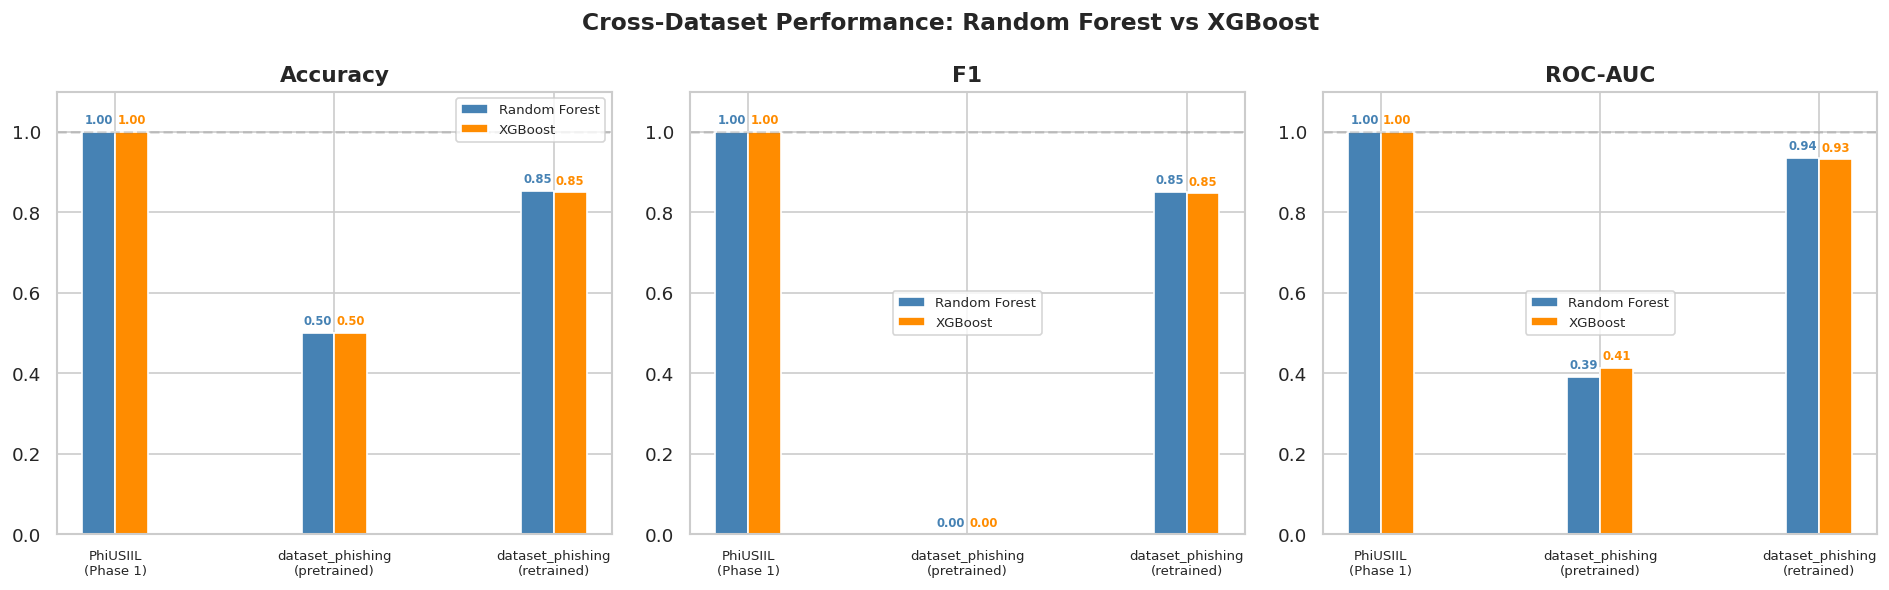

In [79]:
# ── 7. Final combined comparison table ───────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

all_results = pd.DataFrame([
    {'Model': 'Random Forest', 'Dataset': 'PhiUSIIL (Phase 1)',               'Accuracy': 1.0000, 'F1': 1.0000, 'ROC-AUC': 1.0000},
    {'Model': 'XGBoost',       'Dataset': 'PhiUSIIL (Phase 1)',               'Accuracy': 1.0000, 'F1': 1.0000, 'ROC-AUC': 1.0000},
    {'Model': 'Random Forest', 'Dataset': 'dataset_phishing (pretrained)',     'Accuracy': 0.5000, 'F1': 0.0000, 'ROC-AUC': 0.3917},
    {'Model': 'XGBoost',       'Dataset': 'dataset_phishing (pretrained)',     'Accuracy': 0.5000, 'F1': 0.0000, 'ROC-AUC': 0.4139},
    {'Model': 'Random Forest', 'Dataset': 'dataset_phishing (retrained)',      'Accuracy': 0.8543, 'F1': 0.8513, 'ROC-AUC': 0.9359},
    {'Model': 'XGBoost',       'Dataset': 'dataset_phishing (retrained)',      'Accuracy': 0.8504, 'F1': 0.8473, 'ROC-AUC': 0.9322},
])

display(all_results.set_index(['Dataset', 'Model']).round(4)
        .style.background_gradient(cmap='RdYlGn', axis=0))

# ── Visual comparison ─────────────────────────────────────────────────
metrics   = ['Accuracy', 'F1', 'ROC-AUC']
datasets  = ['PhiUSIIL\n(Phase 1)', 'dataset_phishing\n(pretrained)', 'dataset_phishing\n(retrained)']
rf_scores  = [[1.0, 1.0, 1.0], [0.5, 0.0, 0.3917], [0.8543, 0.8513, 0.9359]]
xgb_scores = [[1.0, 1.0, 1.0], [0.5, 0.0, 0.4139], [0.8504, 0.8473, 0.9322]]

x     = np.arange(len(datasets))
width = 0.15

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    rf_vals  = [rf_scores[j][i]  for j in range(3)]
    xgb_vals = [xgb_scores[j][i] for j in range(3)]
    ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='steelblue')
    ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='darkorange')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.axhline(1.0, color='grey', linestyle='--', alpha=0.3)
    for j, (rv, xv) in enumerate(zip(rf_vals, xgb_vals)):
        ax.text(j - width/2, rv + 0.02, f'{rv:.2f}', ha='center', fontsize=7, color='steelblue', fontweight='bold')
        ax.text(j + width/2, xv + 0.02, f'{xv:.2f}', ha='center', fontsize=7, color='darkorange', fontweight='bold')

plt.suptitle('Cross-Dataset Performance: Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

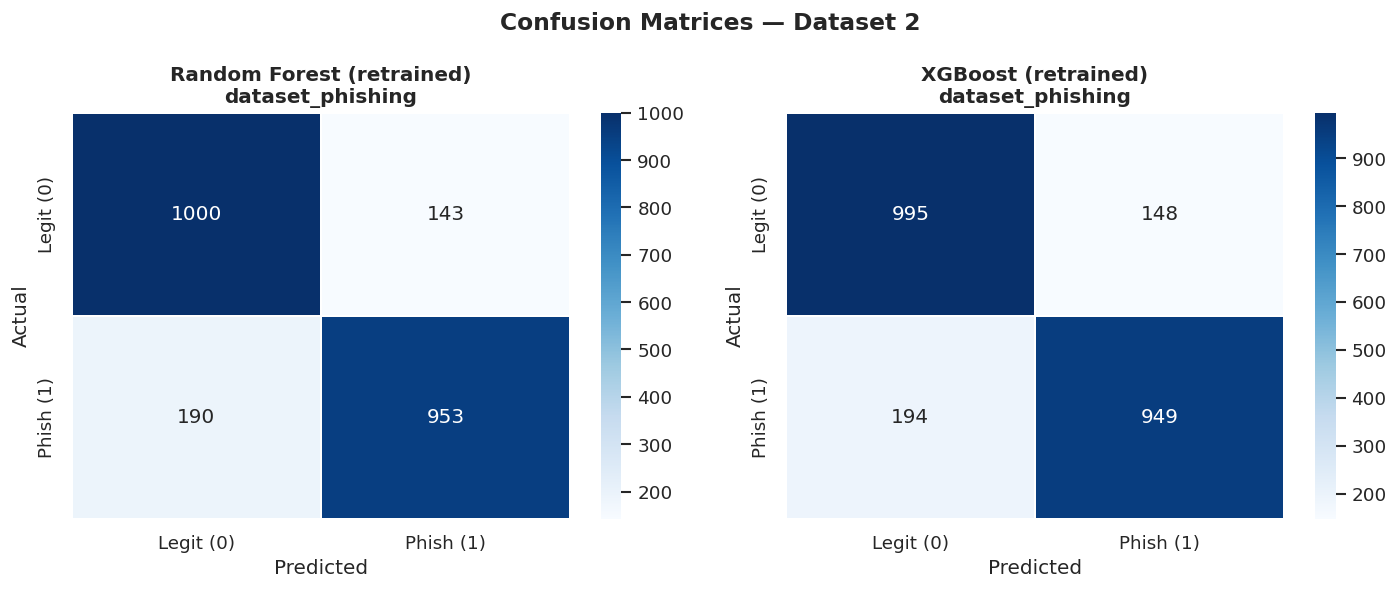

──────────────────────────────────────────────────
  Random Forest (retrained)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       0.84      0.87      0.86      1143
    Phishing       0.87      0.83      0.85      1143

    accuracy                           0.85      2286
   macro avg       0.85      0.85      0.85      2286
weighted avg       0.85      0.85      0.85      2286

──────────────────────────────────────────────────
  XGBoost (retrained)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       0.84      0.87      0.85      1143
    Phishing       0.87      0.83      0.85      1143

    accuracy                           0.85      2286
   macro avg       0.85      0.85      0.85      2286
weighted avg       0.85      0.85      0.85      2286



In [80]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 3A — Confusion Matrices + Classification Reports (Dataset 2)
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, preds in zip(axes,
                            ['Random Forest (retrained)', 'XGBoost (retrained)'],
                            [rf_preds2_new, xgb_preds2_new]):
    cm = confusion_matrix(y2_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit (0)', 'Phish (1)'],
                yticklabels=['Legit (0)', 'Phish (1)'],
                linewidths=1, ax=ax)
    ax.set_title(f'{name}\ndataset_phishing', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Dataset 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification reports
for name, preds in [('Random Forest (retrained)', rf_preds2_new),
                    ('XGBoost (retrained)',        xgb_preds2_new)]:
    print(f'{"─"*50}')
    print(f'  {name}')
    print(f'{"─"*50}')
    print(classification_report(y2_test, preds,
                                target_names=['Legitimate', 'Phishing']))

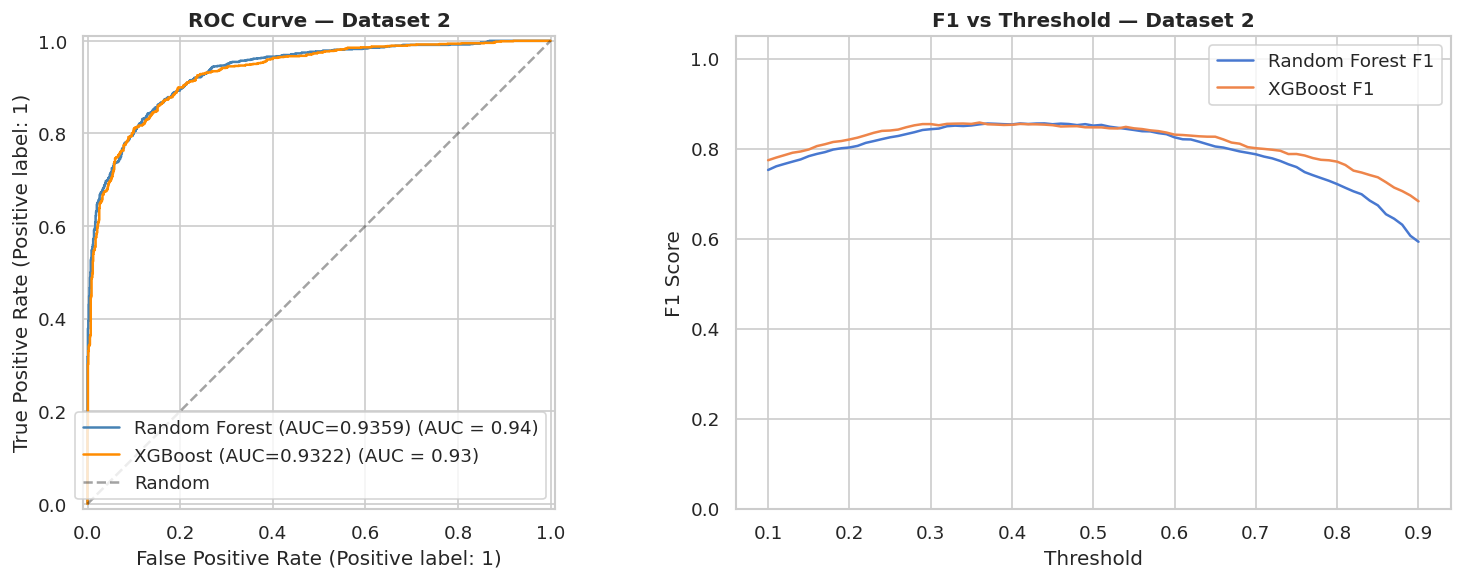

In [81]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 3B — ROC Curves for Dataset 2
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for name, probs, color in [
    ('Random Forest', rf_probs2_new,  'steelblue'),
    ('XGBoost',       xgb_probs2_new, 'darkorange')
]:
    auc = roc_auc_score(y2_test, probs)
    RocCurveDisplay.from_predictions(
        y2_test, probs, name=f'{name} (AUC={auc:.4f})',
        ax=axes[0], color=color
    )
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curve — Dataset 2', fontweight='bold')
axes[0].legend(loc='lower right')

# Threshold analysis
thresholds = np.linspace(0.1, 0.9, 81)
for ax, name, probs in [
    (axes[1], 'Random Forest', rf_probs2_new),
    (axes[1], 'XGBoost',       xgb_probs2_new)
]:
    f1s = [f1_score(y2_test, (probs >= t).astype(int), zero_division=0)
           for t in thresholds]
    ax.plot(thresholds, f1s, label=f'{name} F1')

axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Threshold — Dataset 2', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

,Inference Time (s),Model Size (MB)
RF — PhiUSIIL,4.5463,18.8551
XGB — PhiUSIIL,0.2296,0.1817
RF — dataset_phishing,0.2447,34.9465
XGB — dataset_phishing,0.0409,0.6340


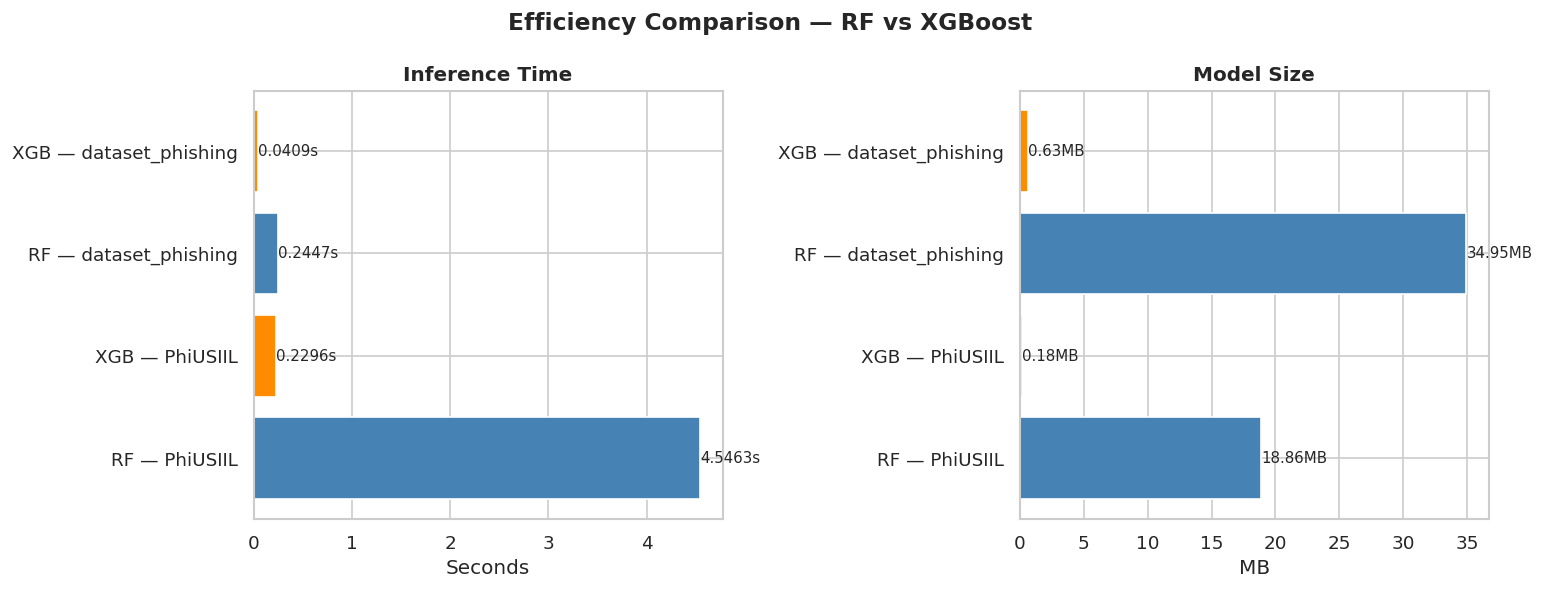

In [82]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 3C — Inference Speed Comparison (Both Datasets)
# ═══════════════════════════════════════════════════════════════════
import time

times = {}

# Dataset 1 (PhiUSIIL)
start = time.time()
rf_best.predict(X_test_imp)
times['RF — PhiUSIIL']  = time.time() - start

start = time.time()
xgb_best.predict(X_test_imp)
times['XGB — PhiUSIIL'] = time.time() - start

# Dataset 2
start = time.time()
rf_new.predict(X2_test)
times['RF — dataset_phishing']  = time.time() - start

start = time.time()
xgb_new.predict(X2_test)
times['XGB — dataset_phishing'] = time.time() - start

# Model sizes
import joblib, sys, io
def model_size_mb(model):
    buf = io.BytesIO()
    joblib.dump(model, buf)
    return buf.tell() / 1e6

sizes = {
    'RF — PhiUSIIL':          model_size_mb(rf_best),
    'XGB — PhiUSIIL':         model_size_mb(xgb_best),
    'RF — dataset_phishing':  model_size_mb(rf_new),
    'XGB — dataset_phishing': model_size_mb(xgb_new),
}

summary = pd.DataFrame({'Inference Time (s)': times, 'Model Size (MB)': sizes}).round(4)
display(summary)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(list(times.keys()), list(times.values()),
             color=['steelblue','darkorange','steelblue','darkorange'])
axes[0].set_xlabel('Seconds')
axes[0].set_title('Inference Time', fontweight='bold')
for i, v in enumerate(times.values()):
    axes[0].text(v + 0.001, i, f'{v:.4f}s', va='center', fontsize=9)

axes[1].barh(list(sizes.keys()), list(sizes.values()),
             color=['steelblue','darkorange','steelblue','darkorange'])
axes[1].set_xlabel('MB')
axes[1].set_title('Model Size', fontweight='bold')
for i, v in enumerate(sizes.values()):
    axes[1].text(v + 0.01, i, f'{v:.2f}MB', va='center', fontsize=9)

plt.suptitle('Efficiency Comparison — RF vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [83]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 3E — Final Master Summary Table (Both Datasets, Both Models)
# ═══════════════════════════════════════════════════════════════════

master = pd.DataFrame([
    # PhiUSIIL
    {'Dataset': 'PhiUSIIL',          'Model': 'Random Forest', 'Train/Test': 'Native',
     'Accuracy': 1.0000, 'Precision': 1.0000, 'Recall': 1.0000, 'F1': 1.0000,
     'ROC-AUC': 1.0000, 'Inference(s)': times['RF — PhiUSIIL'],
     'Size(MB)': sizes['RF — PhiUSIIL']},
    {'Dataset': 'PhiUSIIL',          'Model': 'XGBoost',       'Train/Test': 'Native',
     'Accuracy': 1.0000, 'Precision': 1.0000, 'Recall': 1.0000, 'F1': 1.0000,
     'ROC-AUC': 1.0000, 'Inference(s)': times['XGB — PhiUSIIL'],
     'Size(MB)': sizes['XGB — PhiUSIIL']},
    # Dataset 2 pretrained
    {'Dataset': 'dataset_phishing',  'Model': 'Random Forest', 'Train/Test': 'Pretrained',
     'Accuracy': 0.5000, 'Precision': 0.0000, 'Recall': 0.0000, 'F1': 0.0000,
     'ROC-AUC': 0.3917, 'Inference(s)': None, 'Size(MB)': None},
    {'Dataset': 'dataset_phishing',  'Model': 'XGBoost',       'Train/Test': 'Pretrained',
     'Accuracy': 0.5000, 'Precision': 0.0000, 'Recall': 0.0000, 'F1': 0.0000,
     'ROC-AUC': 0.4139, 'Inference(s)': None, 'Size(MB)': None},
    # Dataset 2 retrained
    {'Dataset': 'dataset_phishing',  'Model': 'Random Forest', 'Train/Test': 'Retrained',
     'Accuracy': 0.8543, 'Precision': 0.8695, 'Recall': 0.8338, 'F1': 0.8513,
     'ROC-AUC': 0.9359, 'Inference(s)': times['RF — dataset_phishing'],
     'Size(MB)': sizes['RF — dataset_phishing']},
    {'Dataset': 'dataset_phishing',  'Model': 'XGBoost',       'Train/Test': 'Retrained',
     'Accuracy': 0.8504, 'Precision': 0.8651, 'Recall': 0.8303, 'F1': 0.8473,
     'ROC-AUC': 0.9322, 'Inference(s)': times['XGB — dataset_phishing'],
     'Size(MB)': sizes['XGB — dataset_phishing']},
])

display(master.set_index(['Dataset', 'Train/Test', 'Model'])
        .style.background_gradient(subset=['Accuracy','F1','ROC-AUC'], cmap='RdYlGn'))

print('\n✅ Phase 3 complete — all results ready for paper and GitHub!')


✅ Phase 3 complete — all results ready for paper and GitHub!


In [84]:
# ── Save retrained models (Dataset 2) ────────────────────────────────
import joblib

joblib.dump(rf_new,  'rf_phishing_model_dataset2.pkl')
joblib.dump(xgb_new, 'xgb_phishing_model_dataset2.pkl')

print('✅ Retrained models saved:')
print('   rf_phishing_model_dataset2.pkl')
print('   xgb_phishing_model_dataset2.pkl')

✅ Retrained models saved:
   rf_phishing_model_dataset2.pkl
   xgb_phishing_model_dataset2.pkl


In [85]:
import shutil

shutil.copy('rf_phishing_model_dataset2.pkl',
    '/content/drive/MyDrive/Phishing URL Detection using Machine Learning/rf_phishing_model_dataset2.pkl')
shutil.copy('xgb_phishing_model_dataset2.pkl',
    '/content/drive/MyDrive/Phishing URL Detection using Machine Learning/xgb_phishing_model_dataset2.pkl')

print('✅ Models copied to Google Drive')

✅ Models copied to Google Drive


## Phase 3 — Final Analysis (Confusion matrices → Export) <a id='7'></a>

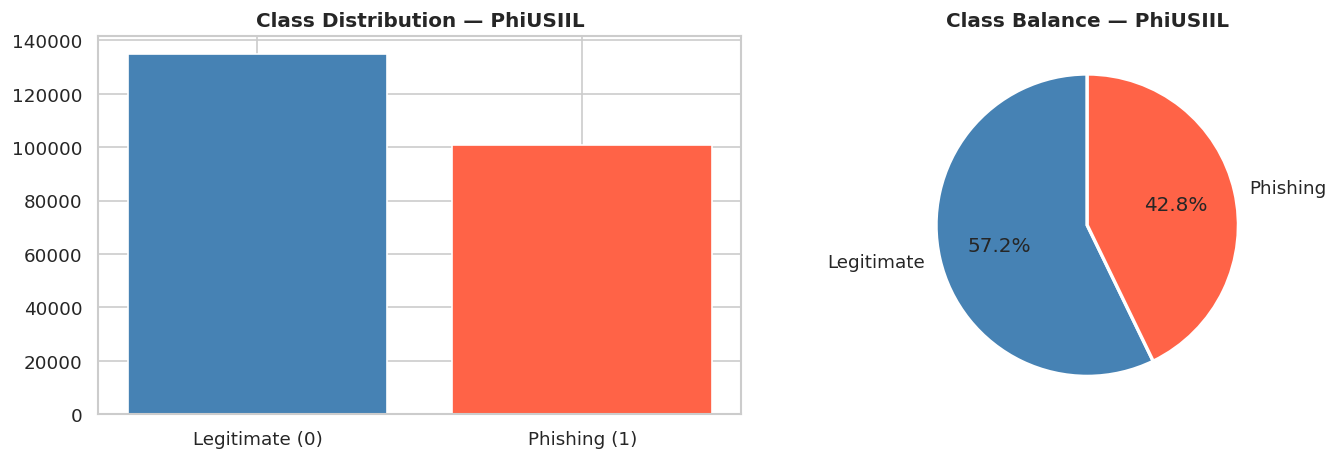

✅ class_distribution.png saved


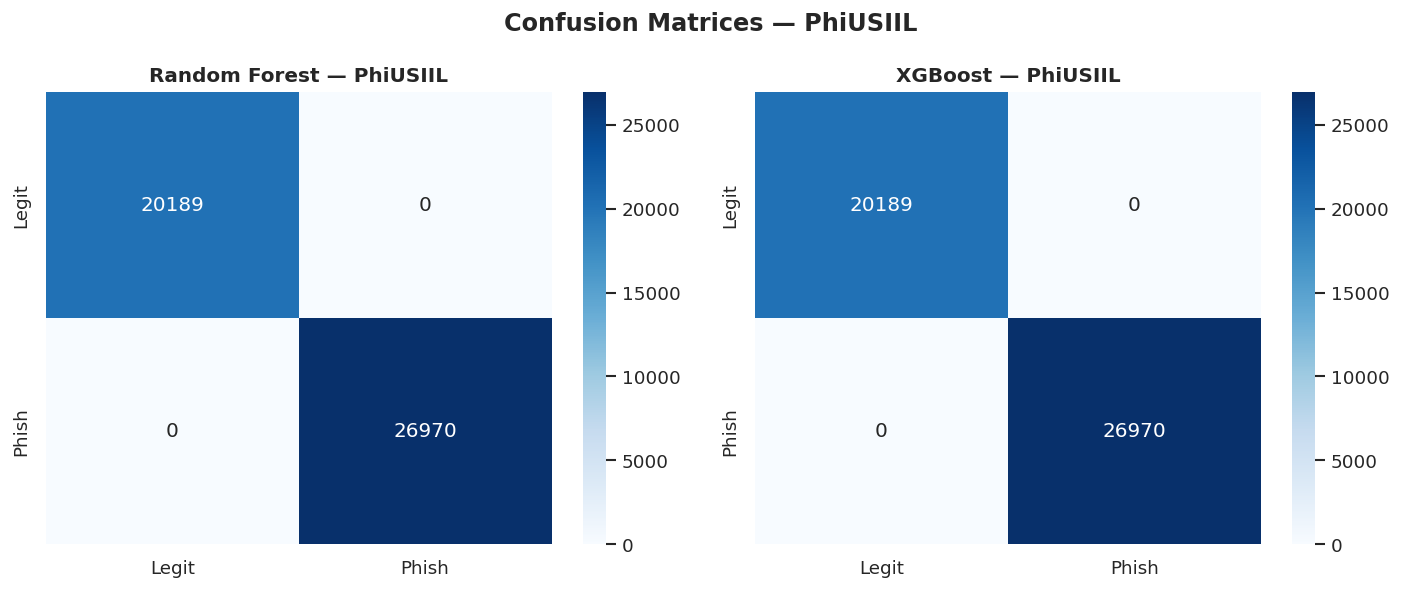

✅ confusion_matrix_phase1.png saved


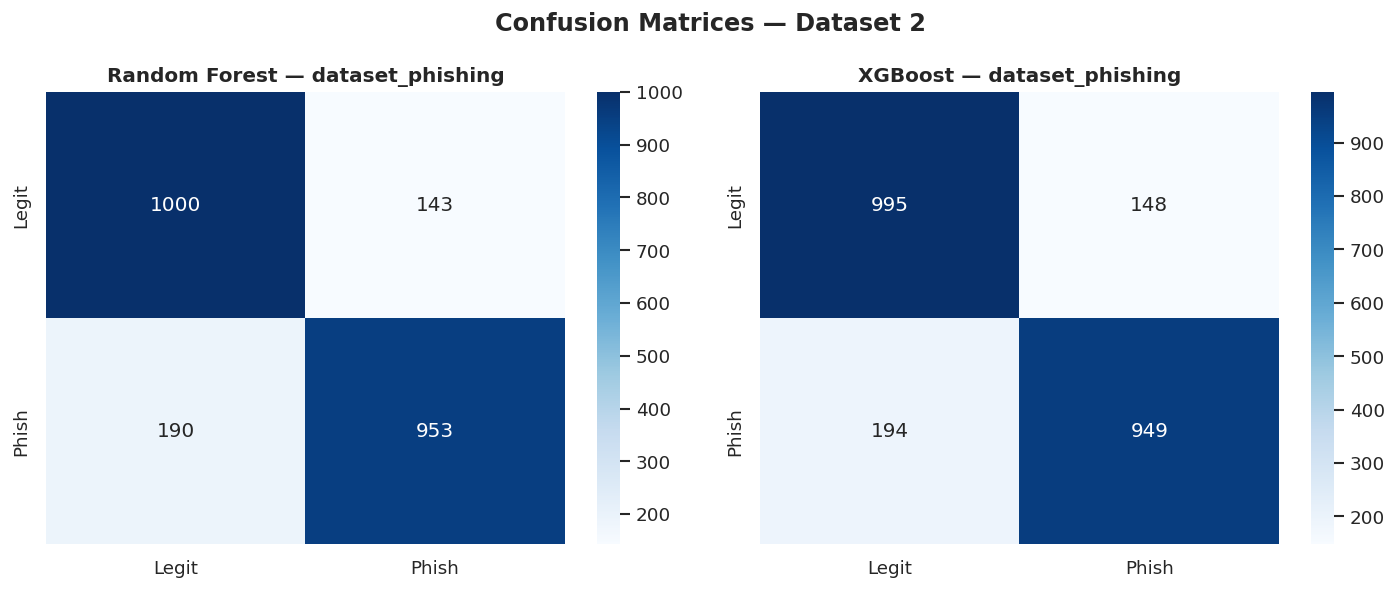

✅ confusion_matrix_phase2.png saved


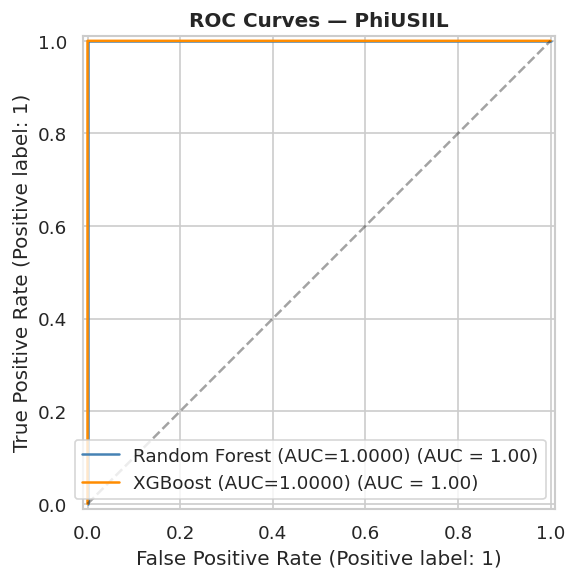

✅ roc_curves_phase1.png saved


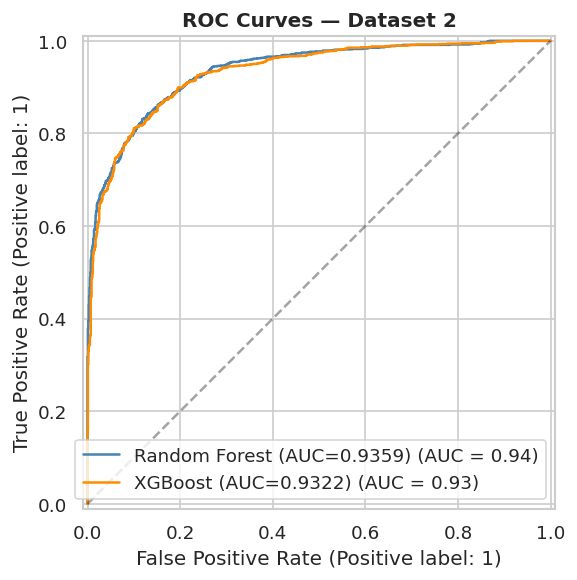

✅ roc_curves_phase2.png saved


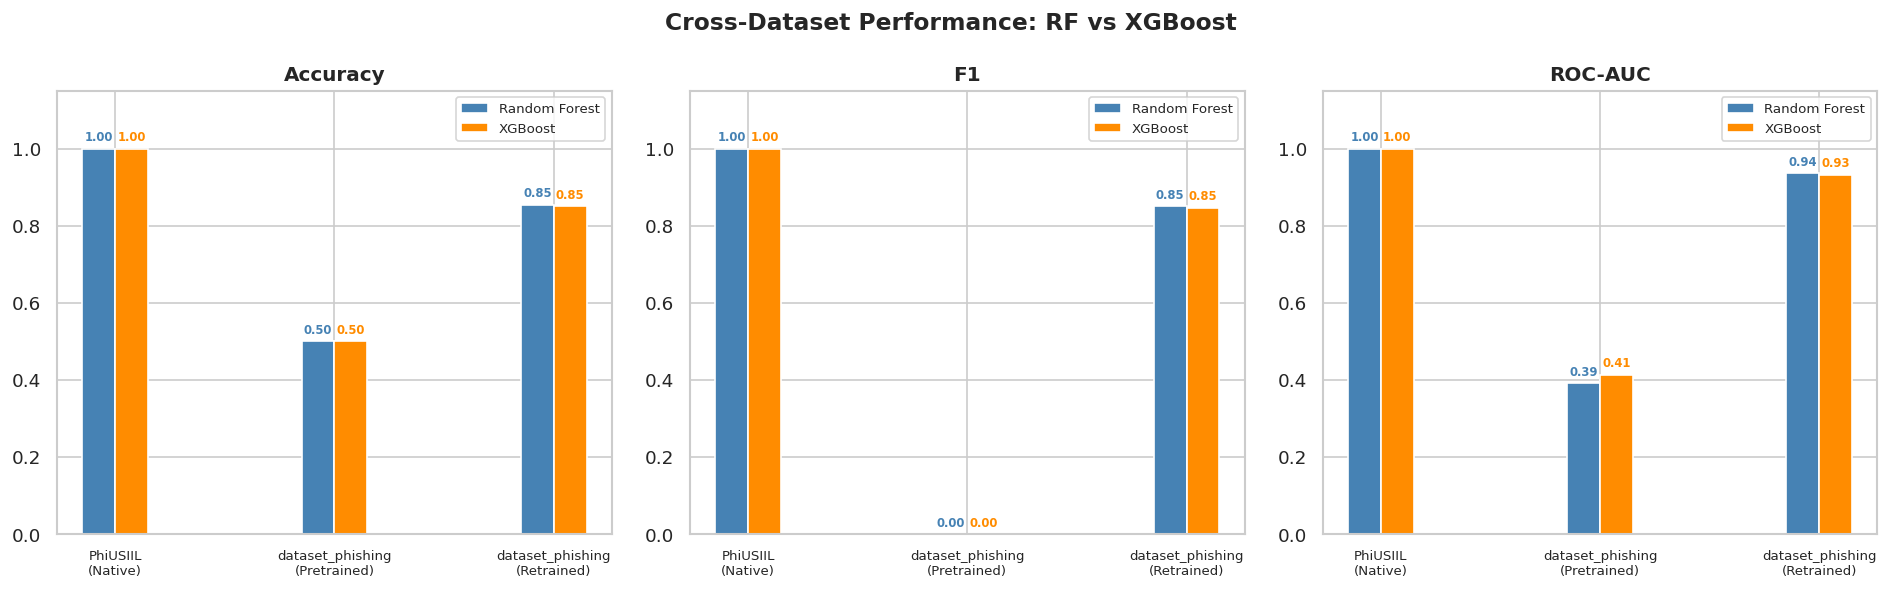

✅ cross_dataset_results.png saved


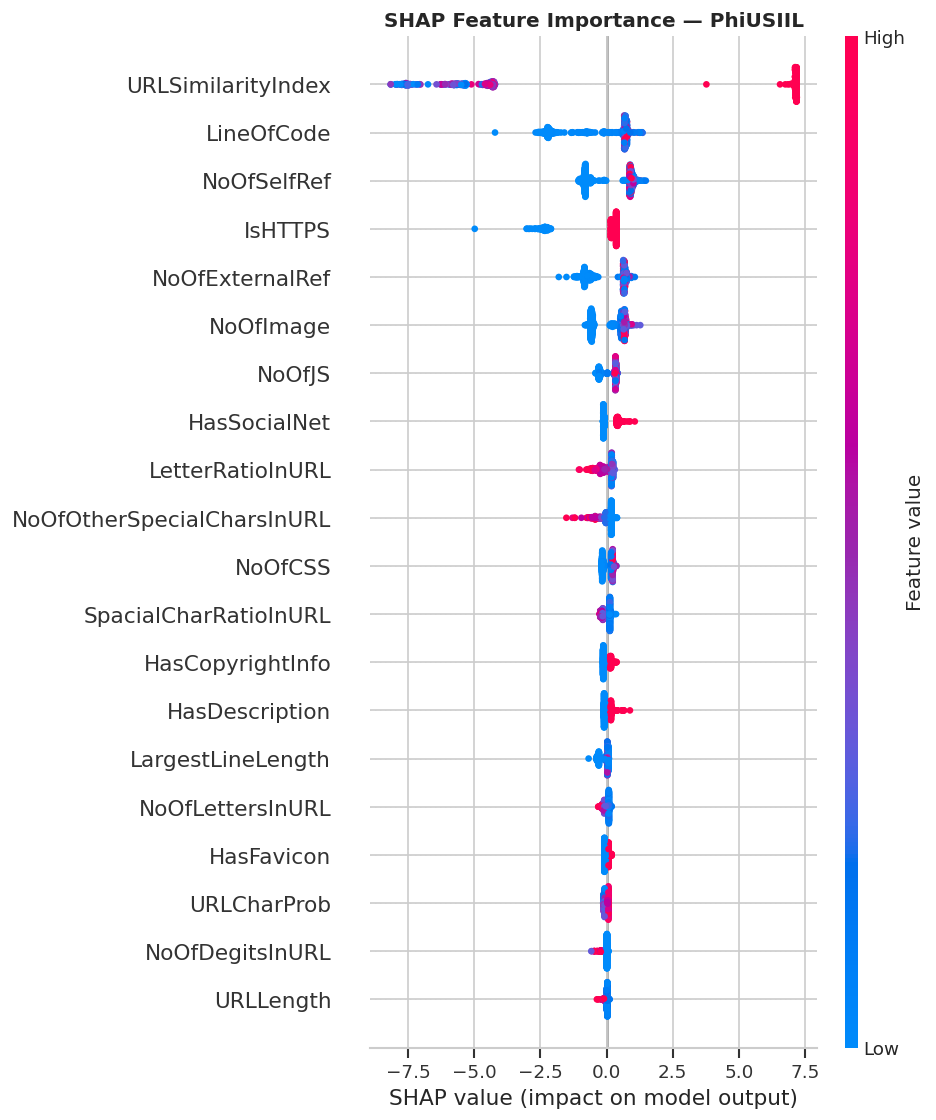

✅ shap_phiusiil.png saved


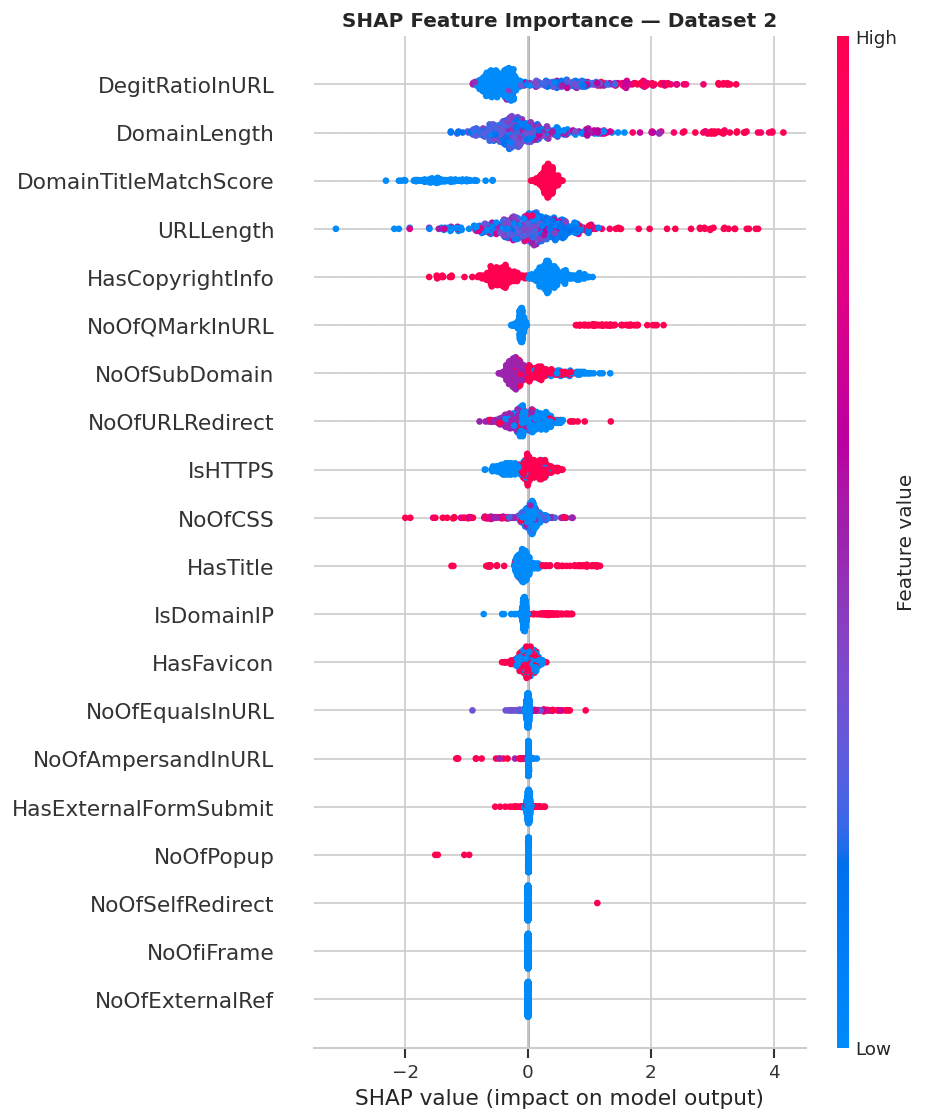

✅ shap_dataset2.png saved


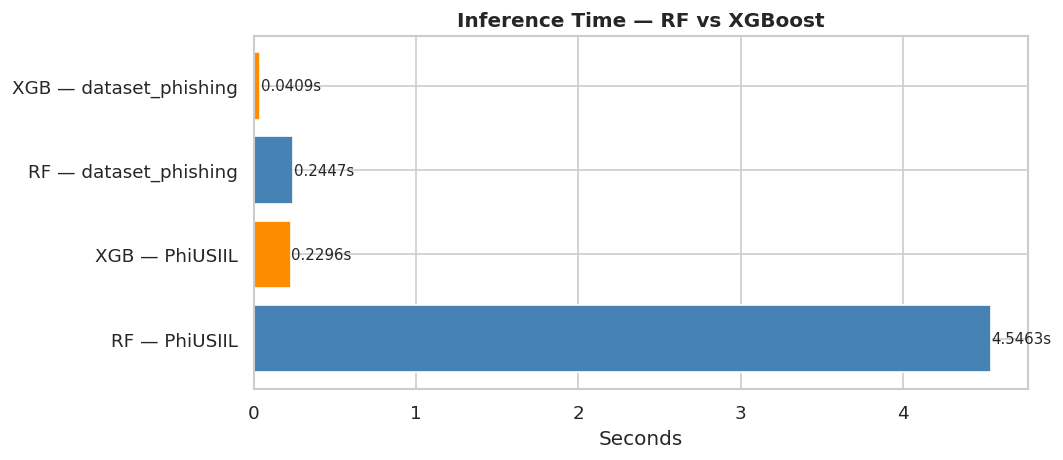

✅ inference_speed.png saved

🎉 All images saved to Google Drive!
   Location: /content/drive/MyDrive/Phishing URL Detection using Machine Learning/images/


In [86]:
# ═══════════════════════════════════════════════════════════════════
# SAVE ALL PLOTS AS IMAGES
# ═══════════════════════════════════════════════════════════════════
import os
import matplotlib.pyplot as plt
import shap

SAVE_DIR = '/content/drive/MyDrive/Phishing URL Detection using Machine Learning/images/'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Class distribution (Phase 1) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df[LABEL_COL].value_counts()
axes[0].bar(['Legitimate (0)', 'Phishing (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution — PhiUSIIL', fontweight='bold')
axes[1].pie(counts.values, labels=['Legitimate', 'Phishing'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance — PhiUSIIL', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ class_distribution.png saved')

# ── 2. Confusion matrices Phase 1 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, preds in zip(axes,
                            ['Random Forest', 'XGBoost'],
                            [rf_preds, xgb_preds]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Phish'],
                yticklabels=['Legit', 'Phish'], ax=ax)
    ax.set_title(f'{name} — PhiUSIIL', fontweight='bold')
plt.suptitle('Confusion Matrices — PhiUSIIL', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix_phase1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ confusion_matrix_phase1.png saved')

# ── 3. Confusion matrices Phase 2 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, preds in zip(axes,
                            ['Random Forest', 'XGBoost'],
                            [rf_preds2_new, xgb_preds2_new]):
    cm = confusion_matrix(y2_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Phish'],
                yticklabels=['Legit', 'Phish'], ax=ax)
    ax.set_title(f'{name} — dataset_phishing', fontweight='bold')
plt.suptitle('Confusion Matrices — Dataset 2', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix_phase2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ confusion_matrix_phase2.png saved')

# ── 4. ROC curves Phase 1 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for name, probs, color in [
    ('Random Forest', rf_probs,  'steelblue'),
    ('XGBoost',       xgb_probs, 'darkorange')
]:
    auc = roc_auc_score(y_test, probs)
    RocCurveDisplay.from_predictions(
        y_test, probs, name=f'{name} (AUC={auc:.4f})', ax=ax, color=color)
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_title('ROC Curves — PhiUSIIL', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'roc_curves_phase1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ roc_curves_phase1.png saved')

# ── 5. ROC curves Phase 2 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for name, probs, color in [
    ('Random Forest', rf_probs2_new,  'steelblue'),
    ('XGBoost',       xgb_probs2_new, 'darkorange')
]:
    auc = roc_auc_score(y2_test, probs)
    RocCurveDisplay.from_predictions(
        y2_test, probs, name=f'{name} (AUC={auc:.4f})', ax=ax, color=color)
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_title('ROC Curves — Dataset 2', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'roc_curves_phase2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ roc_curves_phase2.png saved')

# ── 6. Cross-dataset comparison chart ────────────────────────────────
metrics   = ['Accuracy', 'F1', 'ROC-AUC']
datasets  = ['PhiUSIIL\n(Native)', 'dataset_phishing\n(Pretrained)', 'dataset_phishing\n(Retrained)']
rf_scores  = [[1.0, 1.0, 1.0], [0.5, 0.0, 0.3917], [0.8543, 0.8513, 0.9359]]
xgb_scores = [[1.0, 1.0, 1.0], [0.5, 0.0, 0.4139], [0.8504, 0.8473, 0.9322]]
x = np.arange(len(datasets))
width = 0.15
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (ax, metric) in enumerate(zip(axes, metrics)):
    rf_vals  = [rf_scores[j][i]  for j in range(3)]
    xgb_vals = [xgb_scores[j][i] for j in range(3)]
    ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='steelblue')
    ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='darkorange')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    for j, (rv, xv) in enumerate(zip(rf_vals, xgb_vals)):
        ax.text(j - width/2, rv + 0.02, f'{rv:.2f}', ha='center', fontsize=7,
                color='steelblue', fontweight='bold')
        ax.text(j + width/2, xv + 0.02, f'{xv:.2f}', ha='center', fontsize=7,
                color='darkorange', fontweight='bold')
plt.suptitle('Cross-Dataset Performance: RF vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'cross_dataset_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ cross_dataset_results.png saved')

# ── 7. SHAP Phase 1 ───────────────────────────────────────────────────
explainer1   = shap.TreeExplainer(xgb_best)
shap_values1 = explainer1.shap_values(X_test_imp.iloc[:500])
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values1, X_test_imp.iloc[:500], show=False)
plt.title('SHAP Feature Importance — PhiUSIIL', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'shap_phiusiil.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_phiusiil.png saved')

# ── 8. SHAP Phase 2 ───────────────────────────────────────────────────
explainer2   = shap.TreeExplainer(xgb_new)
shap_values2 = explainer2.shap_values(X2_test.iloc[:500])
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values2, X2_test.iloc[:500], show=False)
plt.title('SHAP Feature Importance — Dataset 2', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'shap_dataset2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_dataset2.png saved')

# ── 9. Inference speed ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
labels = list(times.keys())
values = list(times.values())
colors = ['steelblue','darkorange','steelblue','darkorange']
ax.barh(labels, values, color=colors)
ax.set_xlabel('Seconds')
ax.set_title('Inference Time — RF vs XGBoost', fontweight='bold')
for i, v in enumerate(values):
    ax.text(v + 0.001, i, f'{v:.4f}s', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'inference_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ inference_speed.png saved')

print('\n🎉 All images saved to Google Drive!')
print(f'   Location: {SAVE_DIR}')